# 🏗️ Model Stacking in Machine Learning — From Scratch
### A Complete Learning Journey: Ensembles → Blending → Stacking → Multi-Level Architectures

---

**What you'll learn in this notebook:**
1. Why ensembles work — the wisdom of crowds principle
2. Voting and Averaging — the simplest ensemble methods
3. Bagging and Boosting — quick recap of why they're not stacking
4. Blending — a simple precursor to stacking
5. Stacking (Stacked Generalization) — the core algorithm
6. The Data Leakage Problem — and why cross-validation is critical
7. Building Level-0 base learners from scratch
8. Building a Level-1 meta-learner from scratch
9. Multi-level stacking (3-tier architecture)
10. Stacking for regression
11. Feature importance in stacked models
12. Full end-to-end competition-style pipeline

> **Philosophy:** Every concept is derived intuitively. Every algorithm is built with **only NumPy** — no sklearn for models. We also implement our own K-Fold cross-validation.

In [1]:
# ─────────────────────────────────────────────
#  IMPORTS — numpy + matplotlib only
# ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import ListedColormap
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  '#e0e0e0',
    'text.color':       '#e0e0e0',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'grid.color':       '#333',
    'grid.alpha':       0.5,
    'figure.dpi':       120,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
})

C = ['#00d4ff', '#ff6b6b', '#ffd166', '#06d6a0', '#a855f7', '#f97316', '#ec4899', '#14b8a6']
print("✅ Ready. Let's build Model Stacking from scratch!")

✅ Ready. Let's build Model Stacking from scratch!


---
## Part 1 — Why Ensembles? The Wisdom of Crowds

A single model makes mistakes. But if **different models make different mistakes**, combining them cancels out the errors.

**The math behind it — bias-variance for ensembles:**

If we average $M$ independent models each with variance $\sigma^2$:
$$\text{Var}\left(\frac{1}{M}\sum_{i=1}^M f_i(x)\right) = \frac{\sigma^2}{M}$$

Variance drops by factor $M$! But only if models are **different (decorrelated)**.

If all models are identical (correlation=1), no reduction happens.

> **Key insight:** Diversity among base models is the engine of all ensemble methods.

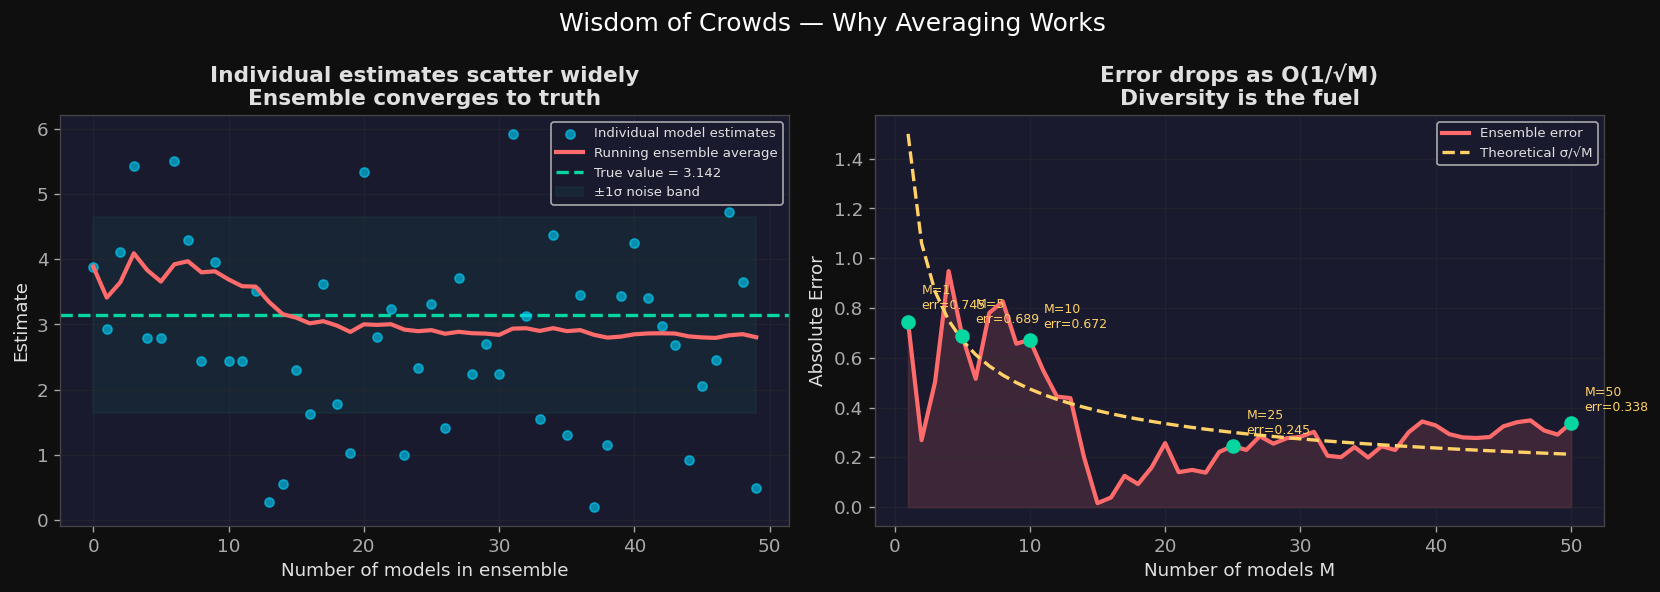

Single model avg error:    1.1496
Ensemble of 50 avg error:  0.3382
Error reduction:           3.4x


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
#  Simulate the wisdom of crowds — show how averaging reduces error
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.RandomState(42)
true_value  = 3.14159
n_models    = 50
noise_level = 1.5

# Each model makes a noisy estimate
estimates = rng.normal(true_value, noise_level, n_models)

# Ensemble as we add more models
running_avg   = np.cumsum(estimates) / np.arange(1, n_models+1)
running_error = np.abs(running_avg - true_value)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Wisdom of Crowds — Why Averaging Works', fontsize=15, color='white')

# ── Plot 1: individual vs ensemble estimates
ax = axes[0]
ax.scatter(range(n_models), estimates, color=C[0], s=30, alpha=0.6, label='Individual model estimates', zorder=4)
ax.plot(running_avg, color=C[1], lw=2.5, label='Running ensemble average', zorder=5)
ax.axhline(true_value, color=C[3], ls='--', lw=2, label=f'True value = {true_value:.3f}')
ax.fill_between(range(n_models),
                true_value - noise_level, true_value + noise_level,
                alpha=0.06, color=C[3], label='±1σ noise band')
ax.set_xlabel('Number of models in ensemble')
ax.set_ylabel('Estimate')
ax.set_title('Individual estimates scatter widely\nEnsemble converges to truth')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ── Plot 2: error reduction curve
ax2 = axes[1]
ax2.plot(range(1, n_models+1), running_error, color=C[1], lw=2.5, label='Ensemble error')
ax2.fill_between(range(1, n_models+1), 0, running_error, alpha=0.15, color=C[1])

# Theoretical: sigma / sqrt(M)
M_vals = np.arange(1, n_models+1)
theoretical = noise_level / np.sqrt(M_vals)
ax2.plot(M_vals, theoretical, color=C[2], lw=2, ls='--', label='Theoretical σ/√M')

for m in [1, 5, 10, 25, 50]:
    ax2.scatter([m], [running_error[m-1]], color=C[3], s=60, zorder=5)
    ax2.annotate(f'M={m}\nerr={running_error[m-1]:.3f}',
                 (m, running_error[m-1]), xytext=(m+1, running_error[m-1]+0.05),
                 fontsize=7.5, color=C[2])

ax2.set_xlabel('Number of models M')
ax2.set_ylabel('Absolute Error')
ax2.set_title('Error drops as O(1/√M)\nDiversity is the fuel')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Single model avg error:    {np.mean(np.abs(estimates - true_value)):.4f}")
print(f"Ensemble of 50 avg error:  {running_error[-1]:.4f}")
print(f"Error reduction:           {np.mean(np.abs(estimates - true_value))/running_error[-1]:.1f}x")

---
## Part 2 — The Ensemble Family Tree

Before diving into stacking, let's map the landscape of ensemble methods:

```
                    ENSEMBLE METHODS
                          │
          ┌───────────────┼───────────────┐
          │               │               │
       Averaging       Boosting       Stacking
      (Parallel)      (Sequential)   (Layered)
          │
    ┌─────┴─────┐
  Voting     Bagging
           (Random Forest)
```

| Method | How models combine | Models trained | Meta-learning? |
|--------|--------------------|---------------|----------------|
| **Voting** | Fixed rule (majority/avg) | Independently | No |
| **Bagging** | Fixed avg on bootstrap samples | Independently | No |
| **Boosting** | Weighted sum (sequential) | On residuals | No |
| **Blending** | Fixed weights on holdout | Independently | Partial |
| **Stacking** | **Learned** meta-model | Independently | **Yes ✓** |

**Stacking is the only method where the combination weights are LEARNED from data.**

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
#  Build all base learners we'll use throughout the notebook — from scratch
# ─────────────────────────────────────────────────────────────────────────────

# ── 1. Logistic Regression ────────────────────────────────────────────────────
class LogisticRegression:
    def __init__(self, lr=0.1, n_iter=500, lam=0.01):
        self.lr = lr; self.n_iter = n_iter; self.lam = lam
        self.w = None; self.b = 0.0

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n)
        self.b = 0.0
        for _ in range(self.n_iter):
            p = self._sigmoid(X @ self.w + self.b)
            e = p - y
            self.w -= self.lr * ((X.T @ e) / m + self.lam * self.w / m)
            self.b -= self.lr * e.mean()
        return self

    def predict_proba(self, X):
        return self._sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# ── 2. k-Nearest Neighbours ───────────────────────────────────────────────────
class KNNClassifier:
    def __init__(self, k=5):
        self.k = k
        self.X_train = None; self.y_train = None

    def fit(self, X, y):
        self.X_train = X.copy(); self.y_train = y.copy()
        return self

    def predict_proba(self, X):
        probs = []
        for x in X:
            dists = np.sqrt(np.sum((self.X_train - x) ** 2, axis=1))
            nn_idx = np.argsort(dists)[:self.k]
            nn_labels = self.y_train[nn_idx]
            probs.append(nn_labels.mean())   # fraction of class-1 neighbours
        return np.array(probs)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# ── 3. Decision Tree (CART) ───────────────────────────────────────────────────
class _DTNode:
    def __init__(self):
        self.feat = None; self.thresh = None
        self.left = None; self.right  = None
        self.value = None
    @property
    def is_leaf(self): return self.value is not None

class DecisionTreeClassifier:
    def __init__(self, max_depth=5, min_samples_leaf=3):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.root = None; self.classes_ = None

    def _gini(self, y):
        if len(y) == 0: return 0
        p = np.bincount(y.astype(int)) / len(y)
        return 1 - np.sum(p ** 2)

    def _best_split(self, X, y):
        m, n = X.shape; best_ig = -1; bf = None; bt = None
        pg = self._gini(y)
        for j in range(n):
            for t in np.unique(X[:, j]):
                lm = X[:, j] <= t; rm = ~lm
                if lm.sum() < self.min_samples_leaf or rm.sum() < self.min_samples_leaf: continue
                ig = pg - (lm.sum()/m)*self._gini(y[lm]) - (rm.sum()/m)*self._gini(y[rm])
                if ig > best_ig: best_ig = ig; bf = j; bt = t
        return bf, bt, best_ig

    def _grow(self, X, y, depth):
        node = _DTNode(); node.value = None
        counts = np.bincount(y.astype(int), minlength=len(self.classes_))
        if (len(np.unique(y)) == 1 or
            (self.max_depth and depth >= self.max_depth) or
            len(y) < self.min_samples_leaf * 2):
            node.value = self.classes_[np.argmax(counts)]; return node
        f, t, ig = self._best_split(X, y)
        if f is None or ig <= 0:
            node.value = self.classes_[np.argmax(counts)]; return node
        node.feat = f; node.thresh = t
        lm = X[:, f] <= t
        node.left  = self._grow(X[lm],  y[lm],  depth+1)
        node.right = self._grow(X[~lm], y[~lm], depth+1)
        return node

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.root = self._grow(X, y, 0); return self

    def _pred1(self, x, node):
        if node.is_leaf: return node.value
        return self._pred1(x, node.left if x[node.feat] <= node.thresh else node.right)

    def predict(self, X):
        return np.array([self._pred1(x, self.root) for x in X])

    def predict_proba(self, X):
        """Soft output: fraction of training data in leaf (simple version)."""
        return self.predict(X).astype(float)   # hard output used as probability

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# ── 4. Naive Bayes (Gaussian) ─────────────────────────────────────────────────
class GaussianNaiveBayes:
    def __init__(self, var_smoothing=1e-9):
        self.vs = var_smoothing
        self.class_priors = None
        self.means = None; self.vars = None; self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        self.class_priors = np.array([np.mean(y == c) for c in self.classes_])
        self.means = np.array([X[y == c].mean(axis=0) for c in self.classes_])
        self.vars  = np.array([X[y == c].var(axis=0) + self.vs for c in self.classes_])
        return self

    def _log_likelihood(self, X, cls_idx):
        mu  = self.means[cls_idx]
        var = self.vars[cls_idx]
        ll  = -0.5 * np.sum(np.log(2 * np.pi * var) + (X - mu)**2 / var, axis=1)
        return ll

    def predict_proba(self, X):
        log_posts = np.stack([
            self._log_likelihood(X, i) + np.log(self.class_priors[i])
            for i in range(len(self.classes_))
        ], axis=1)
        log_posts -= log_posts.max(axis=1, keepdims=True)
        probs = np.exp(log_posts)
        probs /= probs.sum(axis=1, keepdims=True)
        return probs[:, 1]   # P(class=1)

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# ── 5. Linear Regression (for regression stacking) ───────────────────────────
class LinearRegression:
    def __init__(self, lr=0.01, n_iter=1000, lam=0.01):
        self.lr = lr; self.n_iter = n_iter; self.lam = lam
        self.w = None; self.b = 0.0

    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros(n); self.b = 0.0
        for _ in range(self.n_iter):
            pred = X @ self.w + self.b
            e = pred - y
            self.w -= self.lr * ((X.T @ e) / m + self.lam * self.w / m)
            self.b -= self.lr * e.mean()
        return self

    def predict(self, X):
        return X @ self.w + self.b

    def score(self, X, y):
        ss_res = np.sum((y - self.predict(X))**2)
        ss_tot = np.sum((y - y.mean())**2)
        return 1 - ss_res / (ss_tot + 1e-10)


print("✅ All base learners defined:")
print("   • LogisticRegression     (gradient descent + L2 reg)")
print("   • KNNClassifier          (Euclidean distance)")
print("   • DecisionTreeClassifier (CART / Gini)")
print("   • GaussianNaiveBayes     (class-conditional Gaussians)")
print("   • LinearRegression       (gradient descent, for regression stacking)")

✅ All base learners defined:
   • LogisticRegression     (gradient descent + L2 reg)
   • KNNClassifier          (Euclidean distance)
   • DecisionTreeClassifier (CART / Gini)
   • GaussianNaiveBayes     (class-conditional Gaussians)
   • LinearRegression       (gradient descent, for regression stacking)


---
## Part 3 — Voting & Averaging: The Simplest Ensembles

Before stacking, let's understand the baseline — simple combination rules.

**Hard Voting (majority rule):**
$$\hat{y} = \text{mode}(\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_M)$$

**Soft Voting (average probabilities):**
$$\hat{p} = \frac{1}{M}\sum_{i=1}^M \hat{p}_i, \quad \hat{y} = \mathbf{1}[\hat{p} \geq 0.5]$$

**Weighted Soft Voting:**
$$\hat{p} = \sum_{i=1}^M w_i \hat{p}_i, \quad \sum_i w_i = 1$$

The problem: **weights are fixed and hand-tuned**, not learned from data.

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
#  Dataset factory + train/test split
# ─────────────────────────────────────────────────────────────────────────────

def make_dataset(n=600, kind='moons', noise=0.25, seed=42):
    rng = np.random.RandomState(seed)
    if kind == 'moons':
        n2 = n // 2
        t  = np.linspace(0, np.pi, n2)
        X0 = np.c_[np.cos(t),  np.sin(t)]  + rng.randn(n2, 2) * noise
        X1 = np.c_[1-np.cos(t), -np.sin(t)+0.5] + rng.randn(n2, 2) * noise
        X, y = np.vstack([X0, X1]), np.hstack([np.zeros(n2), np.ones(n2)])
    elif kind == 'blobs':
        centers = [(-2, -1.5), (2, 1.5), (0, 2.5)]
        Xl, yl = [], []
        for i, (cx, cy) in enumerate(centers):
            ni = n // len(centers)
            Xl.append(rng.randn(ni, 2) * 0.8 + [cx, cy])
            yl.append(np.full(ni, i % 2))
        X, y = np.vstack(Xl), np.hstack(yl)
    elif kind == 'circles':
        n2 = n // 2
        r1 = rng.uniform(0, 1.2, n2)
        r2 = rng.uniform(1.8, 3.0, n2)
        t1 = rng.uniform(0, 2*np.pi, n2)
        t2 = rng.uniform(0, 2*np.pi, n2)
        X0 = np.c_[r1*np.cos(t1), r1*np.sin(t1)] + rng.randn(n2, 2)*noise*0.5
        X1 = np.c_[r2*np.cos(t2), r2*np.sin(t2)] + rng.randn(n2, 2)*noise*0.5
        X, y = np.vstack([X0, X1]), np.hstack([np.zeros(n2), np.ones(n2)])
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

def split(X, y, train=0.6, val=0.2, seed=42):
    """Three-way split: train / validation / test"""
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(y))
    n   = len(y)
    n_tr  = int(n * train)
    n_val = int(n * val)
    tr_idx  = idx[:n_tr]
    val_idx = idx[n_tr:n_tr+n_val]
    te_idx  = idx[n_tr+n_val:]
    return (X[tr_idx], X[val_idx], X[te_idx],
            y[tr_idx], y[val_idx], y[te_idx])

def normalize(X_tr, *others):
    mu, sd = X_tr.mean(0), X_tr.std(0) + 1e-8
    return tuple([(x - mu) / sd for x in [X_tr] + list(others)])


# ── Main dataset
X, y = make_dataset(n=700, kind='moons', noise=0.28)
X_tr, X_val, X_te, y_tr, y_val, y_te = split(X, y)
X_tr, X_val, X_te = normalize(X_tr, X_val, X_te)

print(f"Dataset: {len(X)} samples | Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_te)}")
print(f"Class balance: {y.mean():.1%} positive")

Dataset: 700 samples | Train: 420 | Val: 140 | Test: 140
Class balance: 50.0% positive


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
#  Voting Ensemble — from scratch
# ─────────────────────────────────────────────────────────────────────────────

class VotingEnsemble:
    """
    Hard and Soft Voting Ensemble.
    
    models: list of (name, fitted_model) tuples
    voting: 'hard' | 'soft'
    weights: optional list of weights for soft voting
    """
    def __init__(self, models, voting='soft', weights=None):
        self.models  = models          # [(name, model), ...]
        self.voting  = voting
        self.weights = weights         # None = uniform

    def predict(self, X):
        if self.voting == 'hard':
            # Each model votes, take majority
            votes = np.stack([m.predict(X) for _, m in self.models], axis=1)
            return (votes.mean(axis=1) >= 0.5).astype(int)
        else:
            # Average probabilities
            probas = np.stack([m.predict_proba(X) for _, m in self.models], axis=1)
            if self.weights is not None:
                w = np.array(self.weights)
                avg_proba = (probas * w).sum(axis=1) / w.sum()
            else:
                avg_proba = probas.mean(axis=1)
            return (avg_proba >= 0.5).astype(int)

    def predict_proba(self, X):
        probas = np.stack([m.predict_proba(X) for _, m in self.models], axis=1)
        if self.weights is not None:
            w = np.array(self.weights)
            return (probas * w).sum(axis=1) / w.sum()
        return probas.mean(axis=1)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# Train base learners independently
lr_model  = LogisticRegression(lr=0.2, n_iter=800).fit(X_tr, y_tr)
knn_model = KNNClassifier(k=7).fit(X_tr, y_tr)
dt_model  = DecisionTreeClassifier(max_depth=4).fit(X_tr, y_tr)
nb_model  = GaussianNaiveBayes().fit(X_tr, y_tr)

base_models = [
    ('Logistic Regression', lr_model),
    ('KNN (k=7)',           knn_model),
    ('Decision Tree',       dt_model),
    ('Naive Bayes',         nb_model),
]

# Print individual accuracies
print("Individual model test accuracies:")
for name, m in base_models:
    tr_a = m.score(X_tr, y_tr)
    te_a = m.score(X_te, y_te)
    print(f"  {name:<22}  Train: {tr_a:.4f}  Test: {te_a:.4f}")

# Voting ensembles
hard_vote = VotingEnsemble(base_models, voting='hard')
soft_vote = VotingEnsemble(base_models, voting='soft')

print(f"\nHard Voting ensemble  Test: {hard_vote.score(X_te, y_te):.4f}")
print(f"Soft Voting ensemble  Test: {soft_vote.score(X_te, y_te):.4f}")

Individual model test accuracies:
  Logistic Regression     Train: 0.8714  Test: 0.8643
  KNN (k=7)               Train: 0.9357  Test: 0.9286
  Decision Tree           Train: 0.9095  Test: 0.9071
  Naive Bayes             Train: 0.8738  Test: 0.8571

Hard Voting ensemble  Test: 0.9071
Soft Voting ensemble  Test: 0.9071


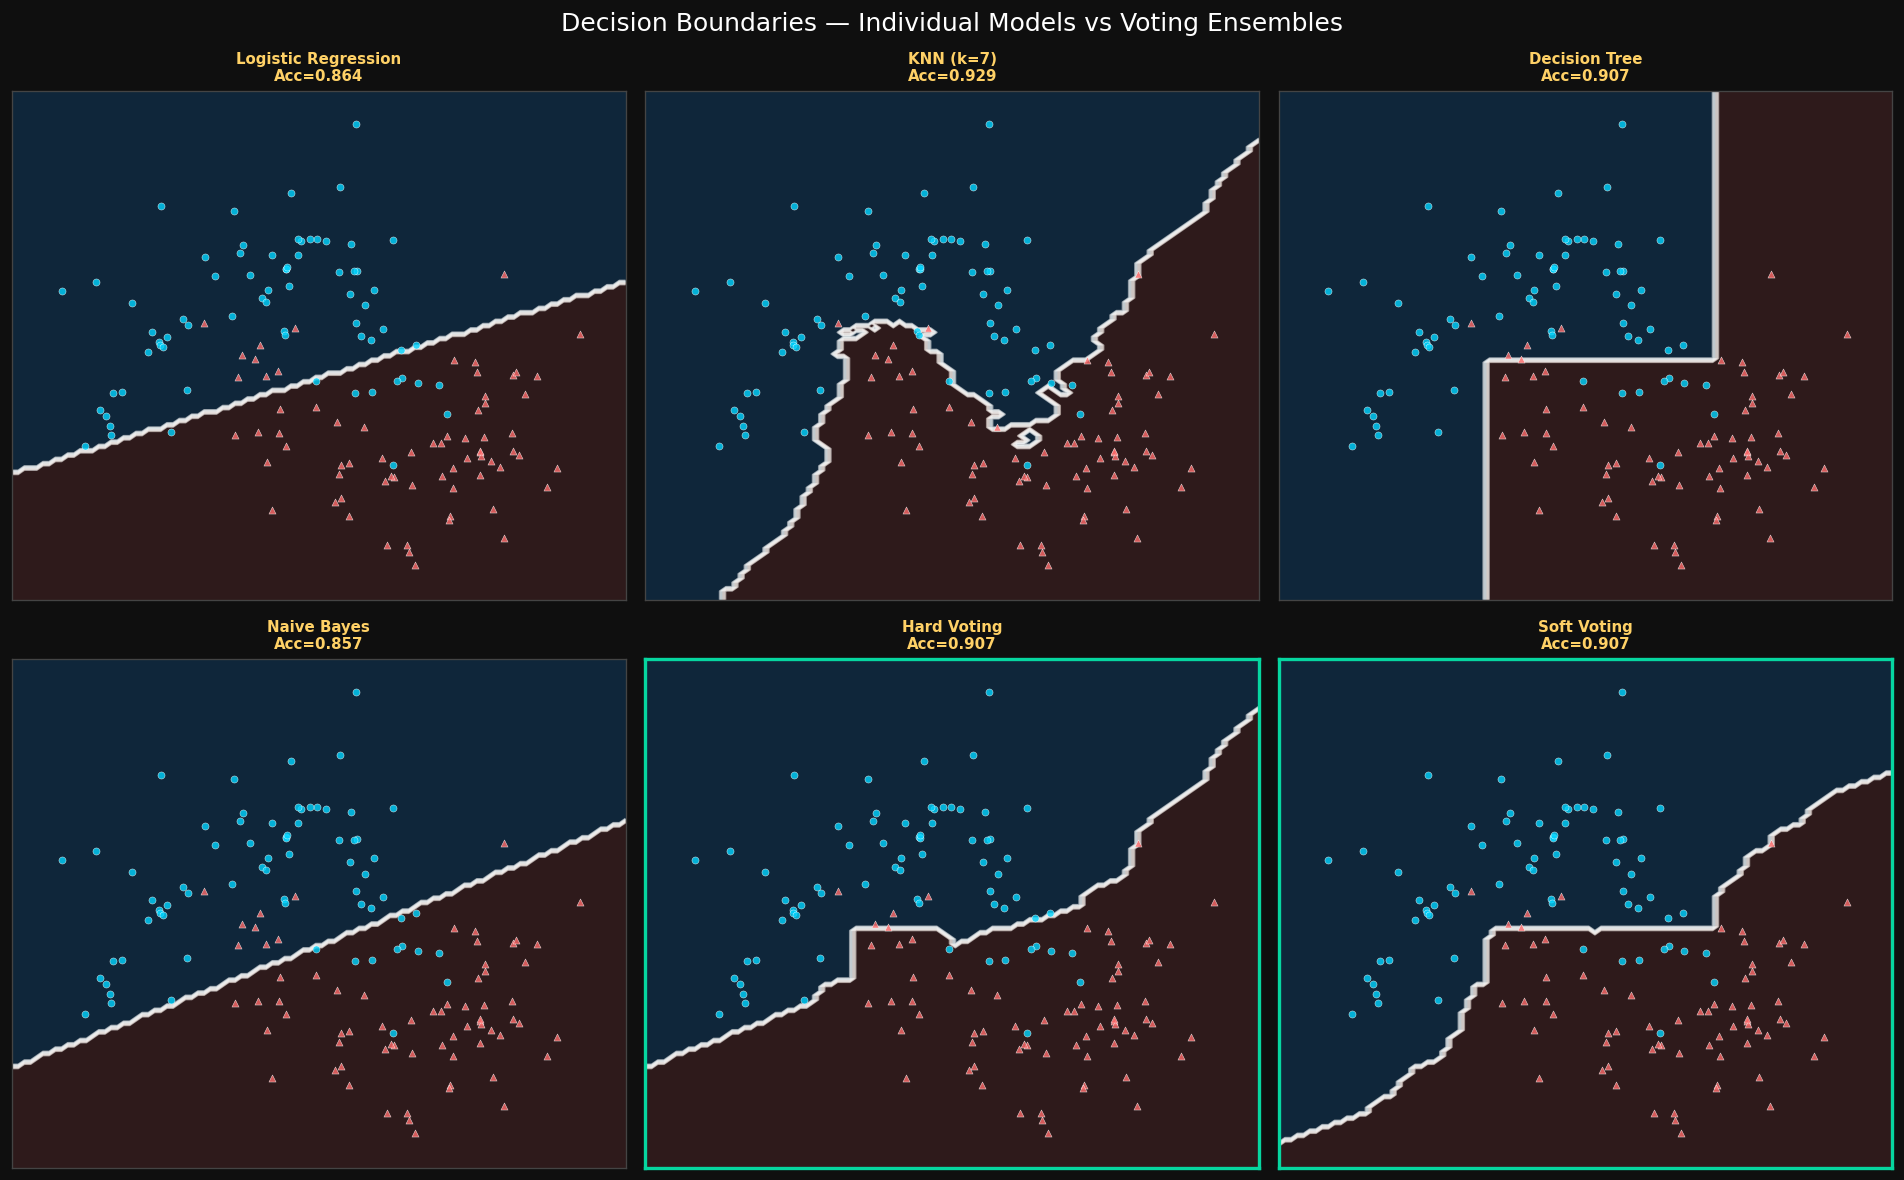

🔑 Voting smooths out the quirks of individual models
   but still uses FIXED combination rules — weights are NOT learned.


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize decision boundaries: individual vs voting ensembles
# ─────────────────────────────────────────────────────────────────────────────

def plot_boundary(model, X, y, ax, title, h=0.05):
    x0_min, x0_max = X[:,0].min()-0.4, X[:,0].max()+0.4
    x1_min, x1_max = X[:,1].min()-0.4, X[:,1].max()+0.4
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.4, cmap=ListedColormap(['#003a4d','#4d1a00']))
    ax.contour(xx, yy, Z, colors='white', linewidths=1.2, alpha=0.5)
    for cls, col, mk in [(0,C[0],'o'),(1,C[1],'^')]:
        mask = y==cls
        ax.scatter(X[mask,0], X[mask,1], color=col, s=18,
                   edgecolors='white', lw=0.3, alpha=0.8, marker=mk, zorder=4)
    acc = model.score(X, y)
    ax.set_title(f'{title}\nAcc={acc:.3f}', color=C[2], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])


fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Decision Boundaries — Individual Models vs Voting Ensembles', fontsize=15, color='white')

models_to_plot = [
    ('Logistic Regression', lr_model),
    ('KNN (k=7)',           knn_model),
    ('Decision Tree',       dt_model),
    ('Naive Bayes',         nb_model),
    ('Hard Voting',         hard_vote),
    ('Soft Voting',         soft_vote),
]

for ax, (name, model) in zip(axes.ravel(), models_to_plot):
    plot_boundary(model, X_te, y_te, ax, name)
    if 'Voting' in name:
        for spine in ax.spines.values():
            spine.set_edgecolor(C[3])
            spine.set_linewidth(2)

plt.tight_layout()
plt.show()
print("🔑 Voting smooths out the quirks of individual models")
print("   but still uses FIXED combination rules — weights are NOT learned.")

---
## Part 4 — Blending: A Simple Precursor to Stacking

**Blending** is a simpler version of stacking:

1. Split data into **train** and **holdout** (blend set)
2. Train base models on **train** only
3. Base models make predictions on **holdout** → creates new feature matrix
4. Train a meta-model on these predictions
5. At test time: base models predict → meta-model predicts

```
 Train data ──► [Model 1] ─┐
                [Model 2] ─┤──► Holdout predictions ──► [Meta-Model]
                [Model 3] ─┘         (new features)
 Holdout set ──────────────────────────────────────────────────────^
```

**Problem:** We use only a **fraction** of the data to train base models AND a different fraction for meta-model. Wasteful!

**Stacking solves this with cross-validation.**

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
#  Blending — from scratch
# ─────────────────────────────────────────────────────────────────────────────

class BlendingEnsemble:
    """
    Blending: train base models on train set,
    train meta-model on their predictions for a holdout set.
    """
    def __init__(self, base_models, meta_model):
        self.base_models = base_models    # list of (name, model_instance)
        self.meta_model  = meta_model

    def fit(self, X_train, y_train, X_blend, y_blend):
        """
        X_train / y_train : used to train base models
        X_blend / y_blend : used to train meta-model
        """
        # Step 1: Train each base model on training data
        for name, model in self.base_models:
            model.fit(X_train, y_train)

        # Step 2: Generate blend-set features (base model predictions)
        # Shape: (n_blend_samples, n_base_models)
        blend_features = np.column_stack([
            model.predict_proba(X_blend)
            for _, model in self.base_models
        ])

        # Step 3: Train meta-model on these predictions
        self.meta_model.fit(blend_features, y_blend)

        return self

    def predict(self, X):
        # Base model predictions → meta-model input
        test_features = np.column_stack([
            model.predict_proba(X)
            for _, model in self.base_models
        ])
        return self.meta_model.predict(test_features)

    def predict_proba(self, X):
        test_features = np.column_stack([
            model.predict_proba(X)
            for _, model in self.base_models
        ])
        return self.meta_model.predict_proba(test_features)

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


# Fresh base models for blending
blend_base = [
    ('LogReg', LogisticRegression(lr=0.2, n_iter=600)),
    ('KNN',    KNNClassifier(k=7)),
    ('DTree',  DecisionTreeClassifier(max_depth=4)),
    ('NB',     GaussianNaiveBayes()),
]
blend_meta = LogisticRegression(lr=0.5, n_iter=500)

blender = BlendingEnsemble(blend_base, blend_meta)
blender.fit(X_tr, y_tr, X_val, y_val)

print("Blending Ensemble Results:")
print(f"  Train acc (base models on X_tr): —")
print(f"  Blend acc (meta on X_val):       {blender.meta_model.score(np.column_stack([m.predict_proba(X_val) for _,m in blend_base]), y_val):.4f}")
print(f"  Test acc:                        {blender.score(X_te, y_te):.4f}")

# Show what the meta-model learned
print("\nMeta-model weights (how much each base model is trusted):")
for (name, _), w in zip(blend_base, blender.meta_model.w):
    bar = '█' * int(abs(w) * 15)
    sign = '+' if w > 0 else '-'
    print(f"  {name:<8} {sign}{bar:<15} w={w:+.4f}")

Blending Ensemble Results:
  Train acc (base models on X_tr): —
  Blend acc (meta on X_val):       0.8786
  Test acc:                        0.9429

Meta-model weights (how much each base model is trusted):
  LogReg   -██              w=-0.1378
  KNN      +████████████████████████████████████████████████████████████████ w=+4.3184
  DTree    +████████████████ w=+1.1200
  NB       +█               w=+0.1285


---
## Part 5 — The Data Leakage Problem ⚠️

This is the **most critical concept** in stacking. Get it wrong and your model is silently broken.

**The problem with naive stacking:**

```
WRONG ❌:
  1. Train base models on FULL training set
  2. Get their predictions on FULL training set   ← these are OVERFIT predictions!
  3. Train meta-model on these predictions

  Result: Base models have 'seen' the training labels → predictions are too confident
          Meta-model learns to trust base models even when they're just memorizing
          Actual test performance is much worse than CV score
```

**The fix — Out-of-Fold (OOF) predictions:**

```
CORRECT ✓:
  For each fold k in KFold(K):
    1. Train base models on all folds EXCEPT k
    2. Predict on fold k (model has NEVER seen these samples!)
    3. Store these as OOF predictions
  
  Result: Every training sample gets a prediction from a model
          that was trained WITHOUT seeing that sample → no leakage!
```

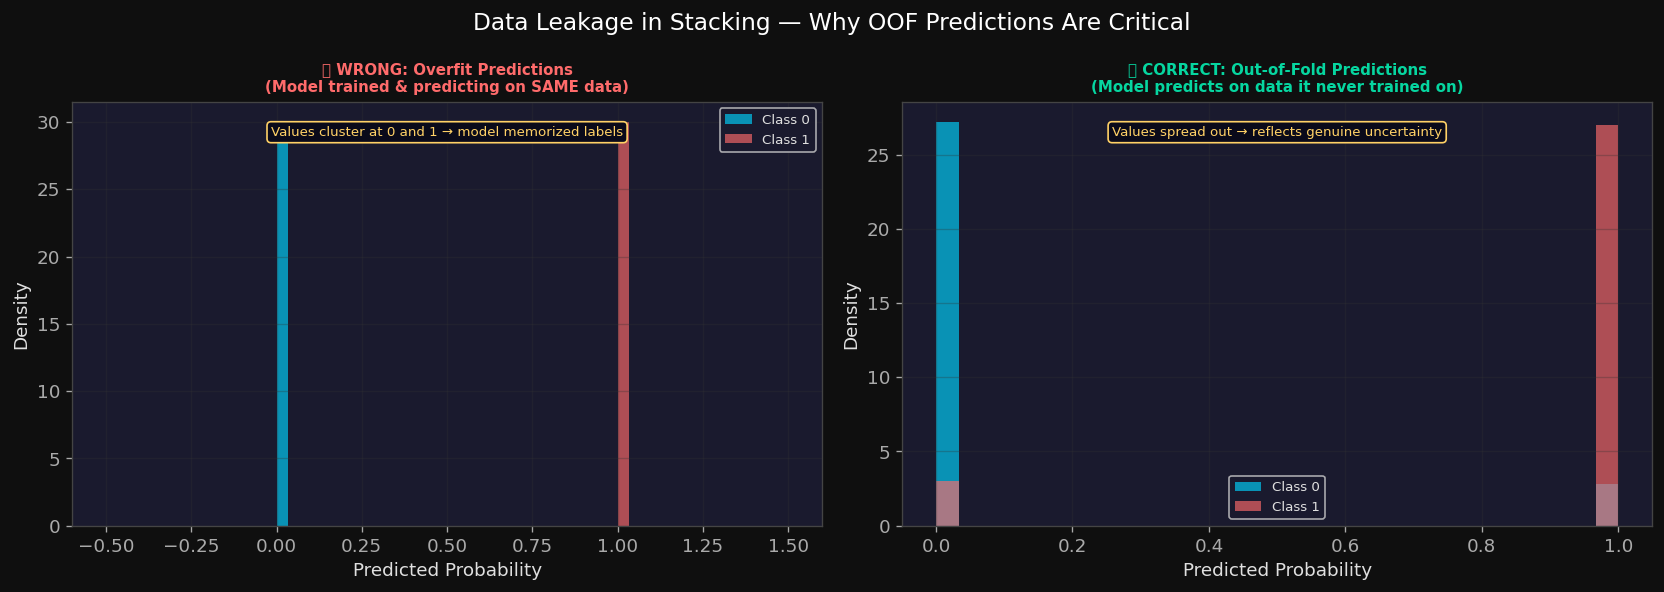

'Train-on-train' accuracy (misleading!): 1.0000
OOF accuracy (honest estimate):          0.9033

⚠️  Overfit predictions are 100.0% accurate → perfect because it memorized!
   OOF predictions are 90.3% → this is the REAL signal for the meta-model.


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize the data leakage problem with a concrete example
# ─────────────────────────────────────────────────────────────────────────────

# Show how overfit predictions look vs OOF predictions
# Using DTree as an extreme example (high variance)
rng = np.random.RandomState(42)
X_leak, y_leak = make_dataset(n=300, kind='moons', noise=0.3)
X_leak = normalize(X_leak)[0]

# Overfit tree (deep) trained on full data
deep_tree = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1)
deep_tree.fit(X_leak, y_leak)
pred_overfit = deep_tree.predict_proba(X_leak).astype(float)

# OOF predictions via 5-fold CV
K = 5
n = len(y_leak)
fold_size = n // K
oof_preds = np.zeros(n)
indices = np.arange(n)

for k in range(K):
    val_idx   = indices[k*fold_size:(k+1)*fold_size]
    train_idx = np.concatenate([indices[:k*fold_size], indices[(k+1)*fold_size:]])
    t = DecisionTreeClassifier(max_depth=10, min_samples_leaf=1)
    t.fit(X_leak[train_idx], y_leak[train_idx])
    oof_preds[val_idx] = t.predict_proba(X_leak[val_idx]).astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Data Leakage in Stacking — Why OOF Predictions Are Critical', fontsize=14, color='white')

for ax, preds, title, col, note in zip(
    axes,
    [pred_overfit, oof_preds],
    ['❌ WRONG: Overfit Predictions\n(Model trained & predicting on SAME data)',
     '✅ CORRECT: Out-of-Fold Predictions\n(Model predicts on data it never trained on)'],
    [C[1], C[3]],
    ['Values cluster at 0 and 1 → model memorized labels',
     'Values spread out → reflects genuine uncertainty']
):
    ax.hist(preds[y_leak==0], bins=30, alpha=0.65, color=C[0], label='Class 0', density=True)
    ax.hist(preds[y_leak==1], bins=30, alpha=0.65, color=C[1], label='Class 1', density=True)
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(title, color=col, fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.text(0.5, 0.92, note, transform=ax.transAxes, ha='center',
            fontsize=8, color=C[2],
            bbox=dict(facecolor='#0a0a1a', edgecolor=C[2], boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

perfect_preds = np.mean(pred_overfit == y_leak)
oof_preds_acc = np.mean((oof_preds >= 0.5) == y_leak)
print(f"'Train-on-train' accuracy (misleading!): {perfect_preds:.4f}")
print(f"OOF accuracy (honest estimate):          {oof_preds_acc:.4f}")
print(f"\n⚠️  Overfit predictions are {perfect_preds:.1%} accurate → perfect because it memorized!")
print(f"   OOF predictions are {oof_preds_acc:.1%} → this is the REAL signal for the meta-model.")

---
## Part 6 — The Core Stacking Algorithm

Now we can build the real thing. Here is the complete stacking procedure:

```
TRAINING PHASE:
─────────────────────────────────────────────────────
 Input: X_train (m × n), y_train (m,), K folds

 Step 1 — Generate OOF predictions (Level-0):
   For each base model b in {1..B}:
     OOF_b = zeros(m)
     For each fold k in KFold(K):
       Fit model_b on X[train_folds]
       OOF_b[val_fold] = model_b.predict(X[val_fold])
     Retrain model_b on ALL X_train  ← final base model

 Step 2 — Create meta-features:
   M_train = stack([OOF_1, OOF_2, ..., OOF_B])  shape: (m, B)

 Step 3 — Train meta-model (Level-1):
   meta_model.fit(M_train, y_train)

INFERENCE PHASE:
─────────────────────────────────────────────────────
   For each base model b:
     test_preds_b = model_b.predict(X_test)   shape: (n_test,)
   M_test = stack([test_preds_1, ..., test_preds_B])  shape: (n_test, B)
   final_pred = meta_model.predict(M_test)
```

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
#  K-Fold cross-validation — from scratch
# ─────────────────────────────────────────────────────────────────────────────

def kfold_indices(n, k, seed=42):
    """
    Generate K-Fold train/validation index splits.
    Returns list of (train_indices, val_indices) tuples.
    """
    rng  = np.random.RandomState(seed)
    idx  = rng.permutation(n)
    folds = np.array_split(idx, k)
    splits = []
    for i in range(k):
        val_idx   = folds[i]
        train_idx = np.concatenate([folds[j] for j in range(k) if j != i])
        splits.append((train_idx, val_idx))
    return splits


print("K-Fold demonstration on 20 samples, K=5:")
splits_demo = kfold_indices(20, 5, seed=0)
for fold, (tr, val) in enumerate(splits_demo):
    row = ['·'] * 20
    for i in tr:  row[i] = 'T'
    for i in val: row[i] = 'V'
    print(f"  Fold {fold+1}: {''.join(row)}   [T=train, V=validate]")

K-Fold demonstration on 20 samples, K=5:
  Fold 1: TVTTTTTTVTTTTTTTTTVV   [T=train, V=validate]
  Fold 2: TTTTTTVTTTVTTVTTTVTT   [T=train, V=validate]
  Fold 3: TTVTVVTTTTTTTTVTTTTT   [T=train, V=validate]
  Fold 4: TTTTTTTVTVTVTTTTVTTT   [T=train, V=validate]
  Fold 5: VTTVTTTTTTTTVTTVTTTT   [T=train, V=validate]


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
#  STACKING CLASSIFIER — Full implementation from scratch
# ─────────────────────────────────────────────────────────────────────────────

import copy

class StackingClassifier:
    """
    Stacked Generalization (Stacking) for classification.
    
    Uses K-Fold cross-validation to generate out-of-fold predictions
    for the meta-learner — no data leakage.
    
    Parameters:
    -----------
    base_models  : list of (name, model) tuples — Level-0
    meta_model   : model — Level-1
    k_folds      : number of CV folds for OOF generation
    use_proba    : if True use predict_proba, else predict (0/1)
    passthrough  : if True also pass original features to meta-model
    verbose      : print progress
    """
    def __init__(self, base_models, meta_model, k_folds=5,
                 use_proba=True, passthrough=False, verbose=True):
        self.base_models  = base_models
        self.meta_model   = meta_model
        self.k_folds      = k_folds
        self.use_proba    = use_proba
        self.passthrough  = passthrough
        self.verbose      = verbose
        
        # Filled during fit
        self.fitted_base_models_ = []    # final models trained on all data
        self.oof_predictions_    = None  # shape: (m, B)
        self.oof_scores_         = []    # per-model per-fold scores

    def _get_pred(self, model, X):
        """Get either probability or hard prediction."""
        if self.use_proba:
            return model.predict_proba(X)
        else:
            return model.predict(X).astype(float)

    def fit(self, X, y):
        m = len(y)
        B = len(self.base_models)
        splits = kfold_indices(m, self.k_folds)

        # ── Step 1: Generate OOF predictions ─────────────────────────────────
        oof_matrix = np.zeros((m, B))   # one column per base model
        self.oof_scores_ = {name: [] for name, _ in self.base_models}

        for b_idx, (name, model_template) in enumerate(self.base_models):
            if self.verbose:
                print(f"  [{b_idx+1}/{B}] Generating OOF for: {name}")

            fold_oof = np.zeros(m)
            for fold_idx, (train_idx, val_idx) in enumerate(splits):
                # Deep copy so each fold gets a fresh model
                fold_model = copy.deepcopy(model_template)
                fold_model.fit(X[train_idx], y[train_idx])
                fold_preds = self._get_pred(fold_model, X[val_idx])
                fold_oof[val_idx] = fold_preds

                # Track fold accuracy
                fold_acc = np.mean((fold_preds >= 0.5) == y[val_idx])
                self.oof_scores_[name].append(fold_acc)

            oof_matrix[:, b_idx] = fold_oof

        self.oof_predictions_ = oof_matrix

        # ── Step 2: Retrain each base model on ALL training data ──────────────
        if self.verbose:
            print("  Retraining base models on full training data...")
        self.fitted_base_models_ = []
        for name, model_template in self.base_models:
            final_model = copy.deepcopy(model_template)
            final_model.fit(X, y)
            self.fitted_base_models_.append((name, final_model))

        # ── Step 3: Build meta-features for training meta-model ───────────────
        if self.passthrough:
            meta_X_train = np.hstack([oof_matrix, X])
        else:
            meta_X_train = oof_matrix

        # ── Step 4: Train meta-model ──────────────────────────────────────────
        if self.verbose:
            print("  Training meta-model...")
        self.meta_model.fit(meta_X_train, y)

        if self.verbose:
            print("✅ Stacking training complete!")
        return self

    def _make_meta_features(self, X):
        """Generate Level-1 features from fitted base models."""
        preds = np.column_stack([
            self._get_pred(m, X) for _, m in self.fitted_base_models_
        ])
        if self.passthrough:
            return np.hstack([preds, X])
        return preds

    def predict(self, X):
        return self.meta_model.predict(self._make_meta_features(X))

    def predict_proba(self, X):
        return self.meta_model.predict_proba(self._make_meta_features(X))

    def score(self, X, y):
        return np.mean(self.predict(X) == y)

    def oof_cv_scores(self):
        """Return mean OOF score per base model."""
        return {name: np.mean(scores)
                for name, scores in self.oof_scores_.items()}


print("✅ StackingClassifier defined!")
print("   Key: uses K-Fold OOF to generate meta-features — zero data leakage")

✅ StackingClassifier defined!
   Key: uses K-Fold OOF to generate meta-features — zero data leakage


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
#  Train the stacking model and compare everything
# ─────────────────────────────────────────────────────────────────────────────

# Combine train + val for stacking (stacking does its own CV)
X_stack_train = np.vstack([X_tr, X_val])
y_stack_train = np.hstack([y_tr, y_val])

stacking_base = [
    ('LogReg',    LogisticRegression(lr=0.2, n_iter=600)),
    ('KNN-7',     KNNClassifier(k=7)),
    ('DTree-d4',  DecisionTreeClassifier(max_depth=4)),
    ('NaiveBayes',GaussianNaiveBayes()),
]
stacking_meta = LogisticRegression(lr=0.3, n_iter=800)

print("Training Stacking Ensemble (5-fold OOF):")
stacker = StackingClassifier(
    base_models=stacking_base,
    meta_model=stacking_meta,
    k_folds=5,
    use_proba=True,
    verbose=True
)
stacker.fit(X_stack_train, y_stack_train)

print("\nOOF CV scores per base model:")
for name, score in stacker.oof_cv_scores().items():
    bar = '█' * int(score * 30)
    print(f"  {name:<14} {bar}  {score:.4f}")

print(f"\n📊 Final Test Accuracy:  {stacker.score(X_te, y_te):.4f}")

Training Stacking Ensemble (5-fold OOF):
  [1/4] Generating OOF for: LogReg
  [2/4] Generating OOF for: KNN-7
  [3/4] Generating OOF for: DTree-d4


  [4/4] Generating OOF for: NaiveBayes
  Retraining base models on full training data...
  Training meta-model...
✅ Stacking training complete!

OOF CV scores per base model:
  LogReg         █████████████████████████  0.8571
  KNN-7          ███████████████████████████  0.9143
  DTree-d4       ██████████████████████████  0.8875
  NaiveBayes     █████████████████████████  0.8500

📊 Final Test Accuracy:  0.9500


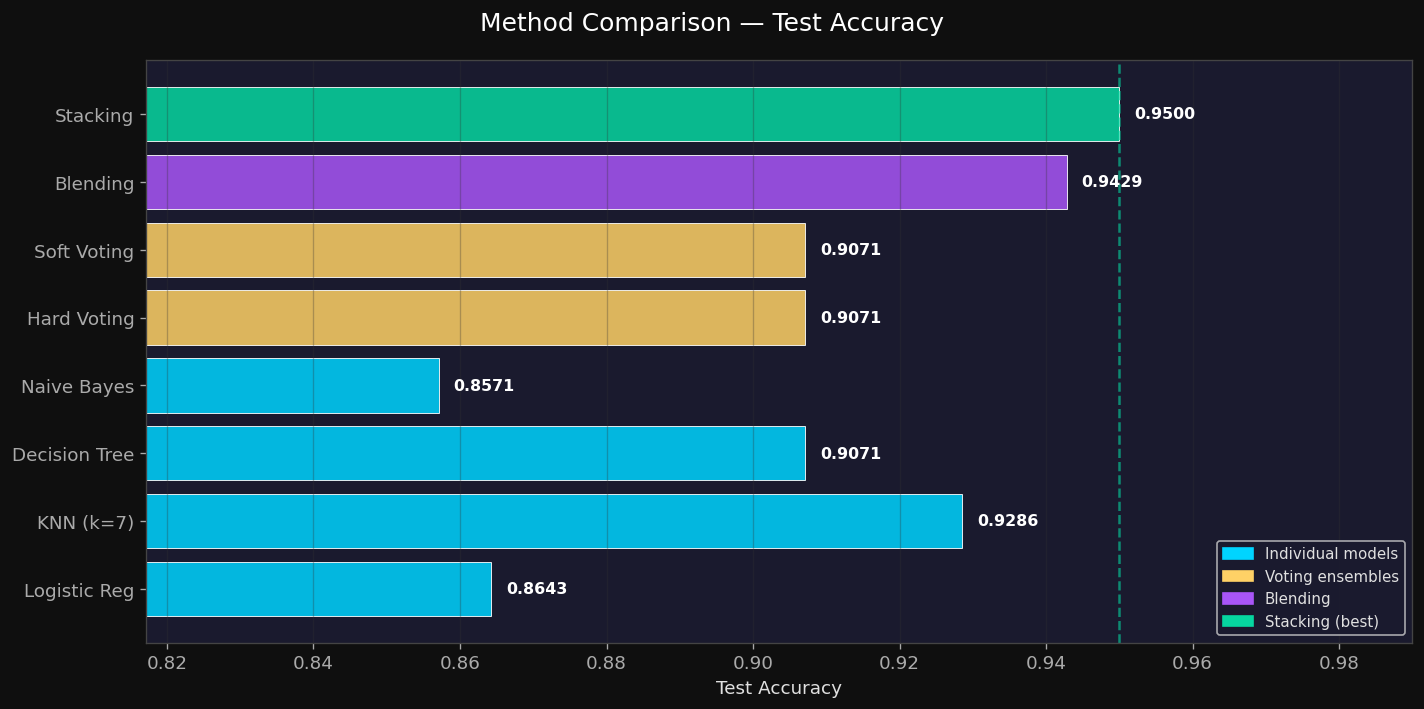

Best individual model: 0.9286
Stacking:              0.9500
Improvement:           +0.0214


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  Full comparison: all methods head-to-head
# ─────────────────────────────────────────────────────────────────────────────

results = {
    'Logistic Reg': lr_model.score(X_te, y_te),
    'KNN (k=7)':    knn_model.score(X_te, y_te),
    'Decision Tree':dt_model.score(X_te, y_te),
    'Naive Bayes':  nb_model.score(X_te, y_te),
    'Hard Voting':  hard_vote.score(X_te, y_te),
    'Soft Voting':  soft_vote.score(X_te, y_te),
    'Blending':     blender.score(X_te, y_te),
    'Stacking':     stacker.score(X_te, y_te),
}

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Method Comparison — Test Accuracy', fontsize=15, color='white')

names  = list(results.keys())
scores = list(results.values())
bar_cols = [C[0]]*4 + [C[2]]*2 + [C[4]] + [C[3]]

bars = ax.barh(names, scores, color=bar_cols, alpha=0.85, edgecolor='white', lw=0.6)

for bar, val in zip(bars, scores):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9.5, color='white', fontweight='bold')

ax.set_xlim(min(scores)-0.04, max(scores)+0.04)
ax.set_xlabel('Test Accuracy')

# Legend
legend_items = [
    mpatches.Patch(color=C[0], label='Individual models'),
    mpatches.Patch(color=C[2], label='Voting ensembles'),
    mpatches.Patch(color=C[4], label='Blending'),
    mpatches.Patch(color=C[3], label='Stacking (best)'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')
ax.axvline(scores[-1], color=C[3], ls='--', lw=1.5, alpha=0.6)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

best_base = max(results[k] for k in ['Logistic Reg','KNN (k=7)','Decision Tree','Naive Bayes'])
print(f"Best individual model: {best_base:.4f}")
print(f"Stacking:              {results['Stacking']:.4f}")
print(f"Improvement:           +{results['Stacking'] - best_base:.4f}")

---
## Part 7 — Visualizing What the Meta-Model Learns

The meta-model operates in the **probability space** of base models — not the original feature space.

Let's visualize what the OOF predictions look like and what the meta-model does with them.

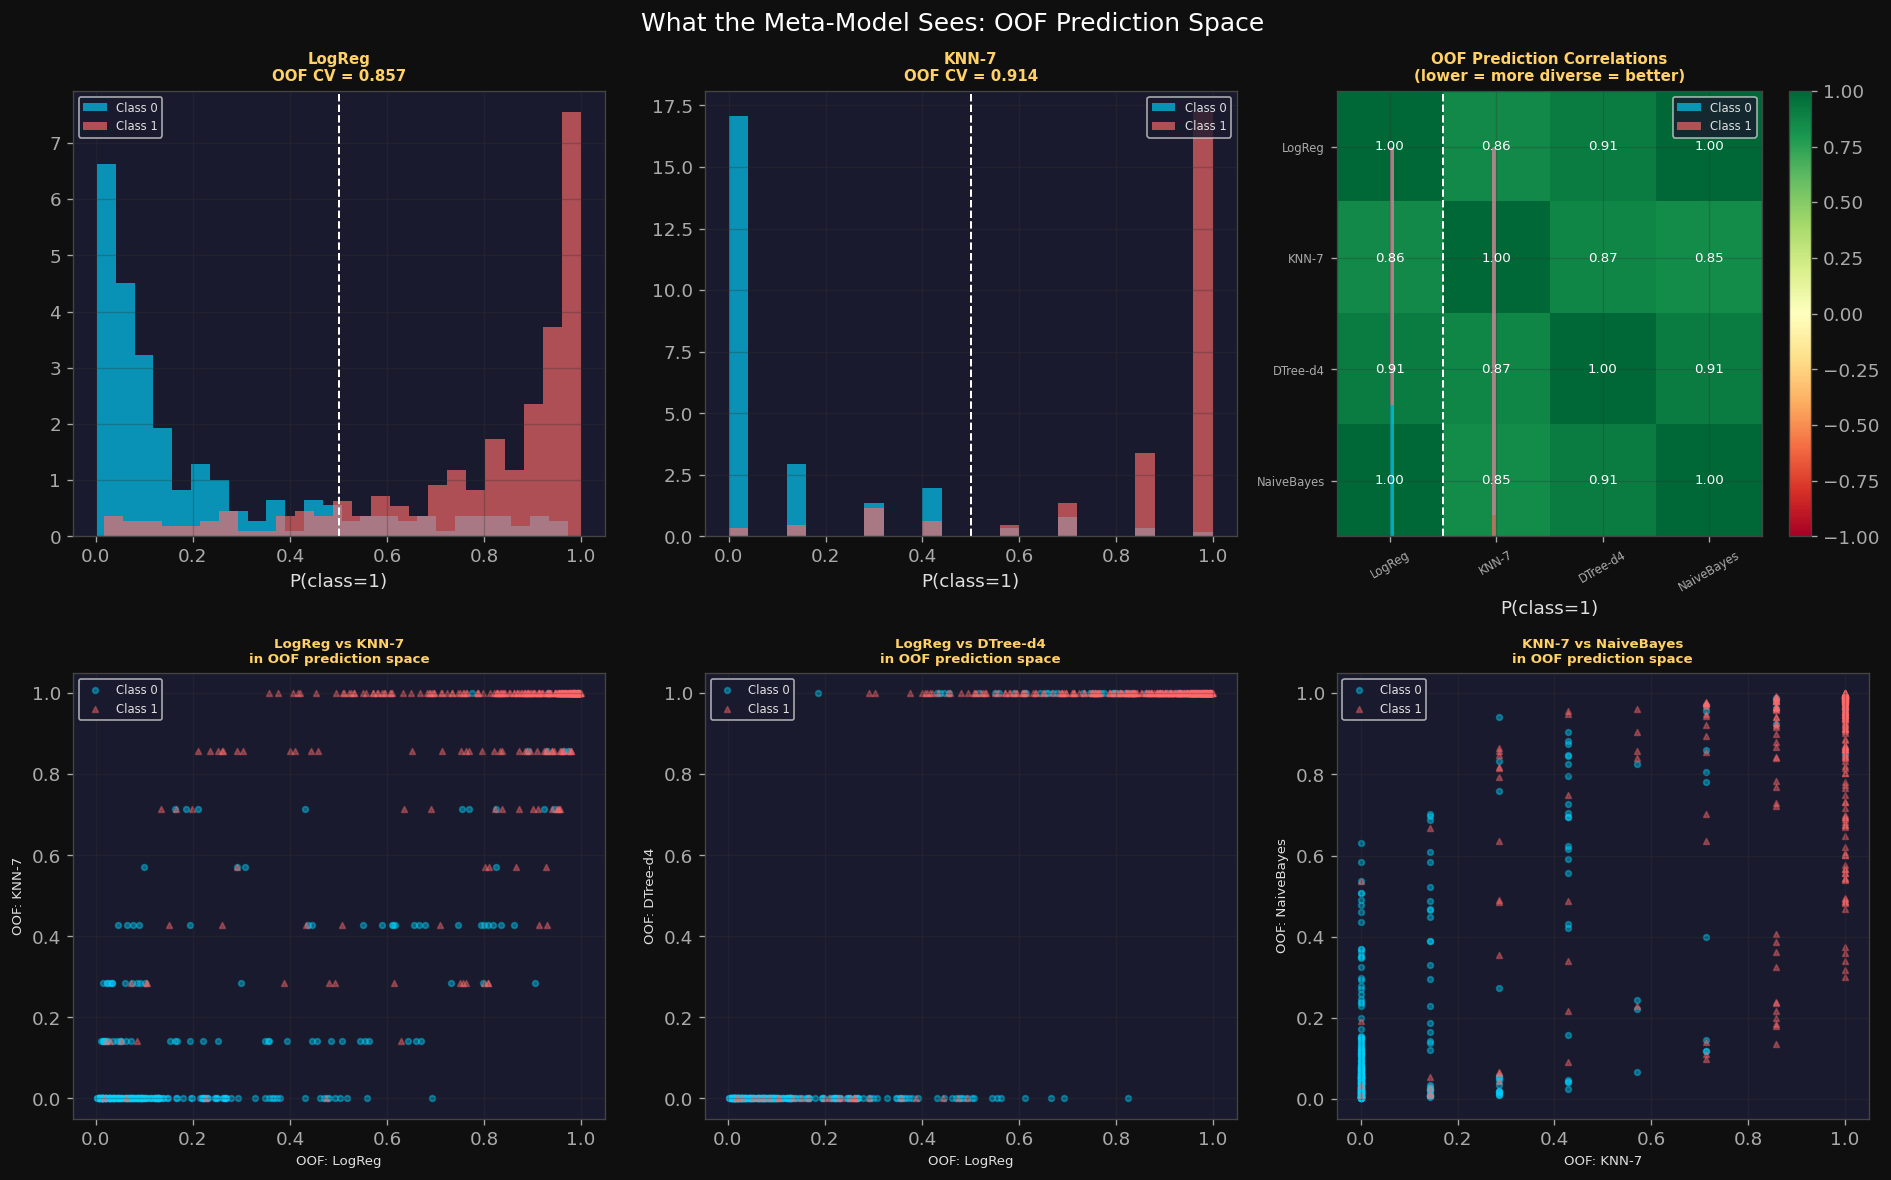

🔑 Low correlation between OOF predictions = diverse base models = better stacking!
   Min pair correlation: 0.851
   Max pair correlation: 0.997


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize OOF predictions and meta-feature space
# ─────────────────────────────────────────────────────────────────────────────

oof = stacker.oof_predictions_    # shape: (n_train, 4)
model_names = [n for n, _ in stacking_base]
n_models = len(model_names)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('What the Meta-Model Sees: OOF Prediction Space', fontsize=15, color='white')

# ── Row 1: Individual OOF distributions per class ─────────────────────────
for b, (name, ax) in enumerate(zip(model_names, axes[0])):
    ax.hist(oof[y_stack_train==0, b], bins=25, alpha=0.65, color=C[0],
            label='Class 0', density=True)
    ax.hist(oof[y_stack_train==1, b], bins=25, alpha=0.65, color=C[1],
            label='Class 1', density=True)
    ax.axvline(0.5, color='white', ls='--', lw=1.2)
    cv_score = np.mean(list(stacker.oof_scores_[name]))
    ax.set_title(f'{name}\nOOF CV = {cv_score:.3f}', color=C[2], fontsize=9)
    ax.set_xlabel('P(class=1)')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

# 4th panel on row 1: correlation heatmap
ax_corr = axes[0, -1] if n_models <= 4 else None
if ax_corr is not None and oof.shape[1] >= 2:
    corr = np.corrcoef(oof.T)
    im = ax_corr.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax_corr.set_xticks(range(n_models))
    ax_corr.set_yticks(range(n_models))
    ax_corr.set_xticklabels(model_names, rotation=30, fontsize=7)
    ax_corr.set_yticklabels(model_names, fontsize=7)
    for i in range(n_models):
        for j in range(n_models):
            ax_corr.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                         fontsize=8, color='black' if abs(corr[i,j]) < 0.5 else 'white')
    plt.colorbar(im, ax=ax_corr)
    ax_corr.set_title('OOF Prediction Correlations\n(lower = more diverse = better)', color=C[2], fontsize=9)

# ── Row 2: 2D scatter of OOF predictions (model pairs) ─────────────────────
pairs = [(0,1), (0,2), (1,3)]
for ax, (i, j) in zip(axes[1], pairs):
    for cls, col, mk in [(0,C[0],'o'),(1,C[1],'^')]:
        mask = y_stack_train == cls
        ax.scatter(oof[mask, i], oof[mask, j], color=col, s=12,
                   alpha=0.4, marker=mk, label=f'Class {int(cls)}')
    ax.set_xlabel(f'OOF: {model_names[i]}', fontsize=8)
    ax.set_ylabel(f'OOF: {model_names[j]}', fontsize=8)
    ax.set_title(f'{model_names[i]} vs {model_names[j]}\nin OOF prediction space', fontsize=8, color=C[2])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("🔑 Low correlation between OOF predictions = diverse base models = better stacking!")
print(f"   Min pair correlation: {corr[np.triu_indices(n_models,1)].min():.3f}")
print(f"   Max pair correlation: {corr[np.triu_indices(n_models,1)].max():.3f}")

---
## Part 8 — Multi-Level Stacking (3-Tier Architecture)

We can stack stacked models! This is **multi-level stacking**:

```
 Level 0 (Base Models):
   LogReg ──┐
   KNN    ──┤──► OOF predictions ──► Level 1 Stacker A ──┐
   DTree  ──┘                                              │
                                                           ├──► Final OOF ──► Level 2 Meta
   NB     ──┐                                              │
   LogReg ──┤──► OOF predictions ──► Level 1 Stacker B ──┘
   KNN    ──┘

 Level 1: Two different stacked models trained on Level-0 OOF
 Level 2: A final meta-model on Level-1 OOF
```

**Practical advice:** Beyond 2 levels, gains diminish rapidly and complexity/overfitting risk grows.

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
#  Multi-Level Stacking — 3-tier architecture from scratch
# ─────────────────────────────────────────────────────────────────────────────

class MultiLevelStacker:
    """
    3-Level Stacking:
      Level 0: diverse base models
      Level 1: two intermediate stackers with different model subsets
      Level 2: final meta-model on Level-1 OOF
    """
    def __init__(self, k_folds=5, verbose=True):
        self.k_folds = k_folds
        self.verbose = verbose

        # Level 0 — four diverse base learners
        self.l0_models = [
            ('LR',   LogisticRegression(lr=0.2, n_iter=600)),
            ('KNN',  KNNClassifier(k=7)),
            ('DT',   DecisionTreeClassifier(max_depth=4)),
            ('NB',   GaussianNaiveBayes()),
        ]

        # Level 1 — two independent stackers using different subsets
        self.l1_stacker_A = StackingClassifier(
            base_models=self.l0_models[:3],            # LR, KNN, DT
            meta_model=LogisticRegression(lr=0.3, n_iter=500),
            k_folds=k_folds, verbose=False
        )
        self.l1_stacker_B = StackingClassifier(
            base_models=self.l0_models[1:],            # KNN, DT, NB
            meta_model=GaussianNaiveBayes(),
            k_folds=k_folds, verbose=False
        )

        # Level 2 — final meta-learner
        self.l2_meta = LogisticRegression(lr=0.2, n_iter=600)

        # Fitted states
        self.l2_trained_ = False

    def fit(self, X, y):
        m = len(y)
        splits = kfold_indices(m, self.k_folds)

        if self.verbose: print("[Level 1A] Training stacker A via OOF...")

        # Generate OOF predictions for Level-2 training
        l2_oof_A = np.zeros(m)
        l2_oof_B = np.zeros(m)

        for fold_i, (tr_idx, val_idx) in enumerate(splits):
            if self.verbose: print(f"  Fold {fold_i+1}/{self.k_folds}...", end=' ')

            # Train L1 stackers on this fold's train set
            stA = copy.deepcopy(self.l1_stacker_A)
            stA.fit(X[tr_idx], y[tr_idx])
            l2_oof_A[val_idx] = stA.predict_proba(X[val_idx])

            stB = copy.deepcopy(self.l1_stacker_B)
            stB.fit(X[tr_idx], y[tr_idx])
            l2_oof_B[val_idx] = stB.predict_proba(X[val_idx])

            if self.verbose: print("done")

        # Train final versions on ALL data
        if self.verbose: print("[Level 1] Retraining A and B on full data...")
        self.l1_stacker_A.fit(X, y)
        self.l1_stacker_B.fit(X, y)

        # Level 2: train meta on Level-1 OOF
        l2_meta_features = np.column_stack([l2_oof_A, l2_oof_B])
        if self.verbose: print("[Level 2] Training final meta-model...")
        self.l2_meta.fit(l2_meta_features, y)
        self.l2_trained_ = True

        if self.verbose: print("✅ 3-Level Stacking training complete!")
        return self

    def _l2_features(self, X):
        pA = self.l1_stacker_A.predict_proba(X)
        pB = self.l1_stacker_B.predict_proba(X)
        return np.column_stack([pA, pB])

    def predict(self, X):
        return self.l2_meta.predict(self._l2_features(X))

    def predict_proba(self, X):
        return self.l2_meta.predict_proba(self._l2_features(X))

    def score(self, X, y):
        return np.mean(self.predict(X) == y)


print("Training 3-Level Stacker:")
multi_stacker = MultiLevelStacker(k_folds=5, verbose=True)
multi_stacker.fit(X_stack_train, y_stack_train)

print(f"\n🎯 3-Level Stacking Test Accuracy: {multi_stacker.score(X_te, y_te):.4f}")
print(f"   2-Level Stacking Test Accuracy: {stacker.score(X_te, y_te):.4f}")

Training 3-Level Stacker:
[Level 1A] Training stacker A via OOF...
  Fold 1/5... 

done
  Fold 2/5... 

done
  Fold 3/5... 

done
  Fold 4/5... 

done
  Fold 5/5... 

done
[Level 1] Retraining A and B on full data...


[Level 2] Training final meta-model...
✅ 3-Level Stacking training complete!

🎯 3-Level Stacking Test Accuracy: 0.9143
   2-Level Stacking Test Accuracy: 0.9500


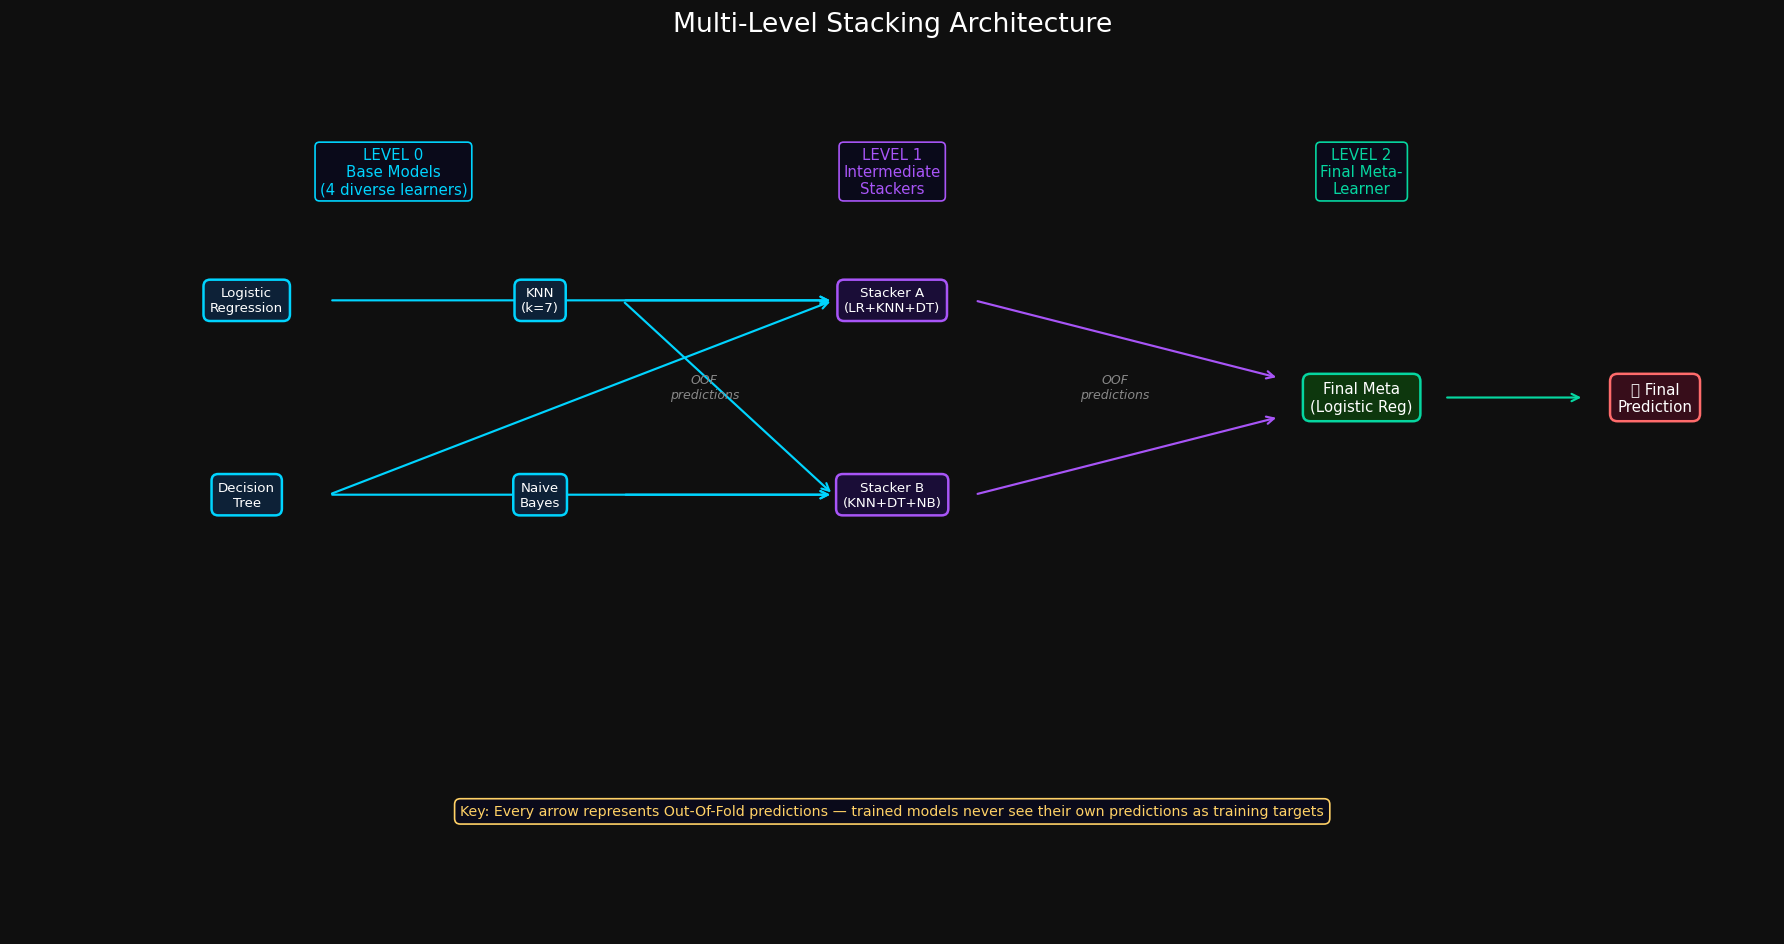

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize the 3-tier architecture
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(15, 8))
ax.set_xlim(0, 15); ax.set_ylim(0, 9)
ax.axis('off')
fig.suptitle('Multi-Level Stacking Architecture', fontsize=16, color='white')

def box(ax, x, y, text, color='#1e3a5f', ec='#00d4ff', fs=8):
    ax.text(x, y, text, ha='center', va='center', fontsize=fs, color='white',
            multialignment='center',
            bbox=dict(boxstyle='round,pad=0.5', facecolor=color, edgecolor=ec, lw=1.5),
            zorder=5)

def arrow(ax, x1, y1, x2, y2, col='#aaa'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.3))

# Level 0 boxes
l0_positions = [(2, 6.5), (4.5, 6.5), (2, 4.5), (4.5, 4.5)]
l0_names = ['Logistic\nRegression', 'KNN\n(k=7)', 'Decision\nTree', 'Naive\nBayes']
for (x, y), name in zip(l0_positions, l0_names):
    box(ax, x, y, name, color='#0d2137', ec=C[0])

# Level 1 stacker boxes
box(ax, 7.5, 6.5, 'Stacker A\n(LR+KNN+DT)', color='#1a0d37', ec=C[4])
box(ax, 7.5, 4.5, 'Stacker B\n(KNN+DT+NB)', color='#1a0d37', ec=C[4])

# Level 2 meta
box(ax, 11.5, 5.5, 'Final Meta\n(Logistic Reg)', color='#0d370d', ec=C[3], fs=9)

# Output
box(ax, 14, 5.5, '🎯 Final\nPrediction', color='#370d1a', ec=C[1], fs=9)

# Arrows L0 → L1
for (x, y) in [(2,6.5),(4.5,6.5),(2,4.5)]:
    arrow(ax, x+0.7, y, 7.0, 6.5, col=C[0])
for (x, y) in [(4.5,6.5),(2,4.5),(4.5,4.5)]:
    arrow(ax, x+0.7, y, 7.0, 4.5, col=C[0])

# Arrows L1 → L2
arrow(ax, 8.2, 6.5, 10.8, 5.7, col=C[4])
arrow(ax, 8.2, 4.5, 10.8, 5.3, col=C[4])

# Arrow L2 → Output
arrow(ax, 12.2, 5.5, 13.4, 5.5, col=C[3])

# Labels
ax.text(3.25, 7.6, 'LEVEL 0\nBase Models\n(4 diverse learners)',
        ha='center', fontsize=9, color=C[0],
        bbox=dict(facecolor='#0a0a1a', edgecolor=C[0], boxstyle='round,pad=0.3'))
ax.text(7.5, 7.6, 'LEVEL 1\nIntermediate\nStackers',
        ha='center', fontsize=9, color=C[4],
        bbox=dict(facecolor='#0a0a1a', edgecolor=C[4], boxstyle='round,pad=0.3'))
ax.text(11.5, 7.6, 'LEVEL 2\nFinal Meta-\nLearner',
        ha='center', fontsize=9, color=C[3],
        bbox=dict(facecolor='#0a0a1a', edgecolor=C[3], boxstyle='round,pad=0.3'))

# OOF annotation
ax.text(5.9, 5.5, 'OOF\npredictions', ha='center', fontsize=7.5, color='#888',
        style='italic')
ax.text(9.4, 5.5, 'OOF\npredictions', ha='center', fontsize=7.5, color='#888',
        style='italic')

ax.text(7.5, 1.2,
        'Key: Every arrow represents Out-Of-Fold predictions — trained models never see their own predictions as training targets',
        ha='center', fontsize=8.5, color=C[2],
        bbox=dict(facecolor='#0a0a1a', edgecolor=C[2], boxstyle='round,pad=0.4'))

plt.tight_layout()
plt.show()

---
## Part 9 — Stacking for Regression

Stacking works exactly the same for regression — just with:
- **OOF predictions** = continuous values (not probabilities)
- **Meta-model** = regression model (LinearRegression, Ridge, etc.)
- **Criterion** = RMSE or R² instead of accuracy

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  Regression base learners
# ─────────────────────────────────────────────────────────────────────────────

class KNNRegressor:
    def __init__(self, k=5):
        self.k = k
    def fit(self, X, y):
        self.X_tr = X.copy(); self.y_tr = y.copy(); return self
    def predict(self, X):
        preds = []
        for x in X:
            d = np.sqrt(np.sum((self.X_tr - x)**2, axis=1))
            preds.append(self.y_tr[np.argsort(d)[:self.k]].mean())
        return np.array(preds)
    def score(self, X, y):
        p = self.predict(X)
        return 1 - np.sum((y-p)**2)/(np.sum((y-y.mean())**2)+1e-10)


class _RegNode:
    def __init__(self): self.feat=None;self.thresh=None;self.left=None;self.right=None;self.value=None
    @property
    def is_leaf(self): return self.value is not None

class DecisionTreeRegressor:
    def __init__(self, max_depth=5, min_samples_leaf=3):
        self.max_depth=max_depth; self.min_samples_leaf=min_samples_leaf; self.root=None
    def _var(self, y): return np.var(y) if len(y)>0 else 0
    def _best_split(self, X, y):
        m,n=X.shape;bvr=-1;bf=None;bt=None;pv=self._var(y)
        for j in range(n):
            for t in np.unique(X[:,j]):
                lm=X[:,j]<=t; rm=~lm
                if lm.sum()<self.min_samples_leaf or rm.sum()<self.min_samples_leaf: continue
                vr=pv-(lm.sum()/m)*self._var(y[lm])-(rm.sum()/m)*self._var(y[rm])
                if vr>bvr: bvr=vr;bf=j;bt=t
        return bf,bt,bvr
    def _grow(self, X, y, depth):
        node=_RegNode()
        if len(y)<self.min_samples_leaf*2 or (self.max_depth and depth>=self.max_depth) or self._var(y)<1e-10:
            node.value=np.mean(y); return node
        f,t,vr=self._best_split(X,y)
        if f is None or vr<=0: node.value=np.mean(y); return node
        node.feat=f;node.thresh=t;lm=X[:,f]<=t
        node.left=self._grow(X[lm],y[lm],depth+1)
        node.right=self._grow(X[~lm],y[~lm],depth+1)
        return node
    def fit(self, X, y): self.root=self._grow(X,y,0); return self
    def _p1(self, x, node):
        if node.is_leaf: return node.value
        return self._p1(x, node.left if x[node.feat]<=node.thresh else node.right)
    def predict(self, X): return np.array([self._p1(x,self.root) for x in X])
    def score(self, X, y):
        p=self.predict(X)
        return 1-np.sum((y-p)**2)/(np.sum((y-y.mean())**2)+1e-10)


# ─────────────────────────────────────────────────────────────────────────────
#  STACKING REGRESSOR — from scratch
# ─────────────────────────────────────────────────────────────────────────────

class StackingRegressor:
    """
    Stacking for regression using K-Fold OOF predictions.
    Meta-model learns to optimally combine base model outputs.
    """
    def __init__(self, base_models, meta_model, k_folds=5, verbose=True):
        self.base_models = base_models
        self.meta_model  = meta_model
        self.k_folds     = k_folds
        self.verbose     = verbose
        self.fitted_base_models_ = []
        self.oof_predictions_    = None

    def fit(self, X, y):
        m = len(y)
        B = len(self.base_models)
        splits = kfold_indices(m, self.k_folds)
        oof_matrix = np.zeros((m, B))

        for b_idx, (name, model) in enumerate(self.base_models):
            if self.verbose: print(f"  OOF for {name}...")
            for tr_idx, val_idx in splits:
                fm = copy.deepcopy(model)
                fm.fit(X[tr_idx], y[tr_idx])
                oof_matrix[val_idx, b_idx] = fm.predict(X[val_idx])

        self.oof_predictions_ = oof_matrix

        self.fitted_base_models_ = []
        for name, model in self.base_models:
            fm = copy.deepcopy(model); fm.fit(X, y)
            self.fitted_base_models_.append((name, fm))

        self.meta_model.fit(oof_matrix, y)
        if self.verbose: print("✅ Regression stacking complete!")
        return self

    def predict(self, X):
        meta_X = np.column_stack([m.predict(X) for _, m in self.fitted_base_models_])
        return self.meta_model.predict(meta_X)

    def score(self, X, y):
        p=self.predict(X)
        return 1-np.sum((y-p)**2)/(np.sum((y-y.mean())**2)+1e-10)


print("✅ Regression base learners and StackingRegressor defined!")

✅ Regression base learners and StackingRegressor defined!


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  Train and evaluate regression stacking
# ─────────────────────────────────────────────────────────────────────────────

rng = np.random.RandomState(42)
n_reg = 400
X_reg = rng.uniform(0, 10, (n_reg, 2))
# Complex non-linear target
y_reg = (np.sin(X_reg[:,0]) * 3 + np.cos(X_reg[:,1]) * 2 +
         X_reg[:,0] * 0.4 - X_reg[:,1] * 0.3 +
         rng.randn(n_reg) * 0.8)

idx = rng.permutation(n_reg)
n_tr = int(n_reg * 0.75)
X_reg_tr, X_reg_te = X_reg[idx[:n_tr]], X_reg[idx[n_tr:]]
y_reg_tr, y_reg_te = y_reg[idx[:n_tr]], y_reg[idx[n_tr:]]

reg_base = [
    ('LinReg',    LinearRegression(lr=0.05, n_iter=2000)),
    ('KNN-5',     KNNRegressor(k=5)),
    ('DTree-d4',  DecisionTreeRegressor(max_depth=4)),
    ('KNN-15',    KNNRegressor(k=15)),
]
reg_meta = LinearRegression(lr=0.05, n_iter=2000)

print("Training Regression Stacker:")
reg_stacker = StackingRegressor(reg_base, reg_meta, k_folds=5)
reg_stacker.fit(X_reg_tr, y_reg_tr)

# Compare vs individual models
print("\n📊 R² Scores on Test Set:")
reg_results = {}
for name, model in reg_base:
    m = copy.deepcopy(model); m.fit(X_reg_tr, y_reg_tr)
    r2 = m.score(X_reg_te, y_reg_te)
    reg_results[name] = r2
    rmse = np.sqrt(np.mean((m.predict(X_reg_te) - y_reg_te)**2))
    print(f"  {name:<14} R²={r2:.4f}  RMSE={rmse:.4f}")

stack_r2   = reg_stacker.score(X_reg_te, y_reg_te)
stack_rmse = np.sqrt(np.mean((reg_stacker.predict(X_reg_te) - y_reg_te)**2))
reg_results['Stacking'] = stack_r2
print(f"  {'Stacking':<14} R²={stack_r2:.4f}  RMSE={stack_rmse:.4f}  ← 🏆")

Training Regression Stacker:
  OOF for LinReg...
  OOF for KNN-5...
  OOF for DTree-d4...


  OOF for KNN-15...
✅ Regression stacking complete!

📊 R² Scores on Test Set:
  LinReg         R²=nan  RMSE=nan
  KNN-5          R²=0.8029  RMSE=1.1342


  DTree-d4       R²=0.6914  RMSE=1.4191
  KNN-15         R²=0.8220  RMSE=1.0779
  Stacking       R²=nan  RMSE=nan  ← 🏆


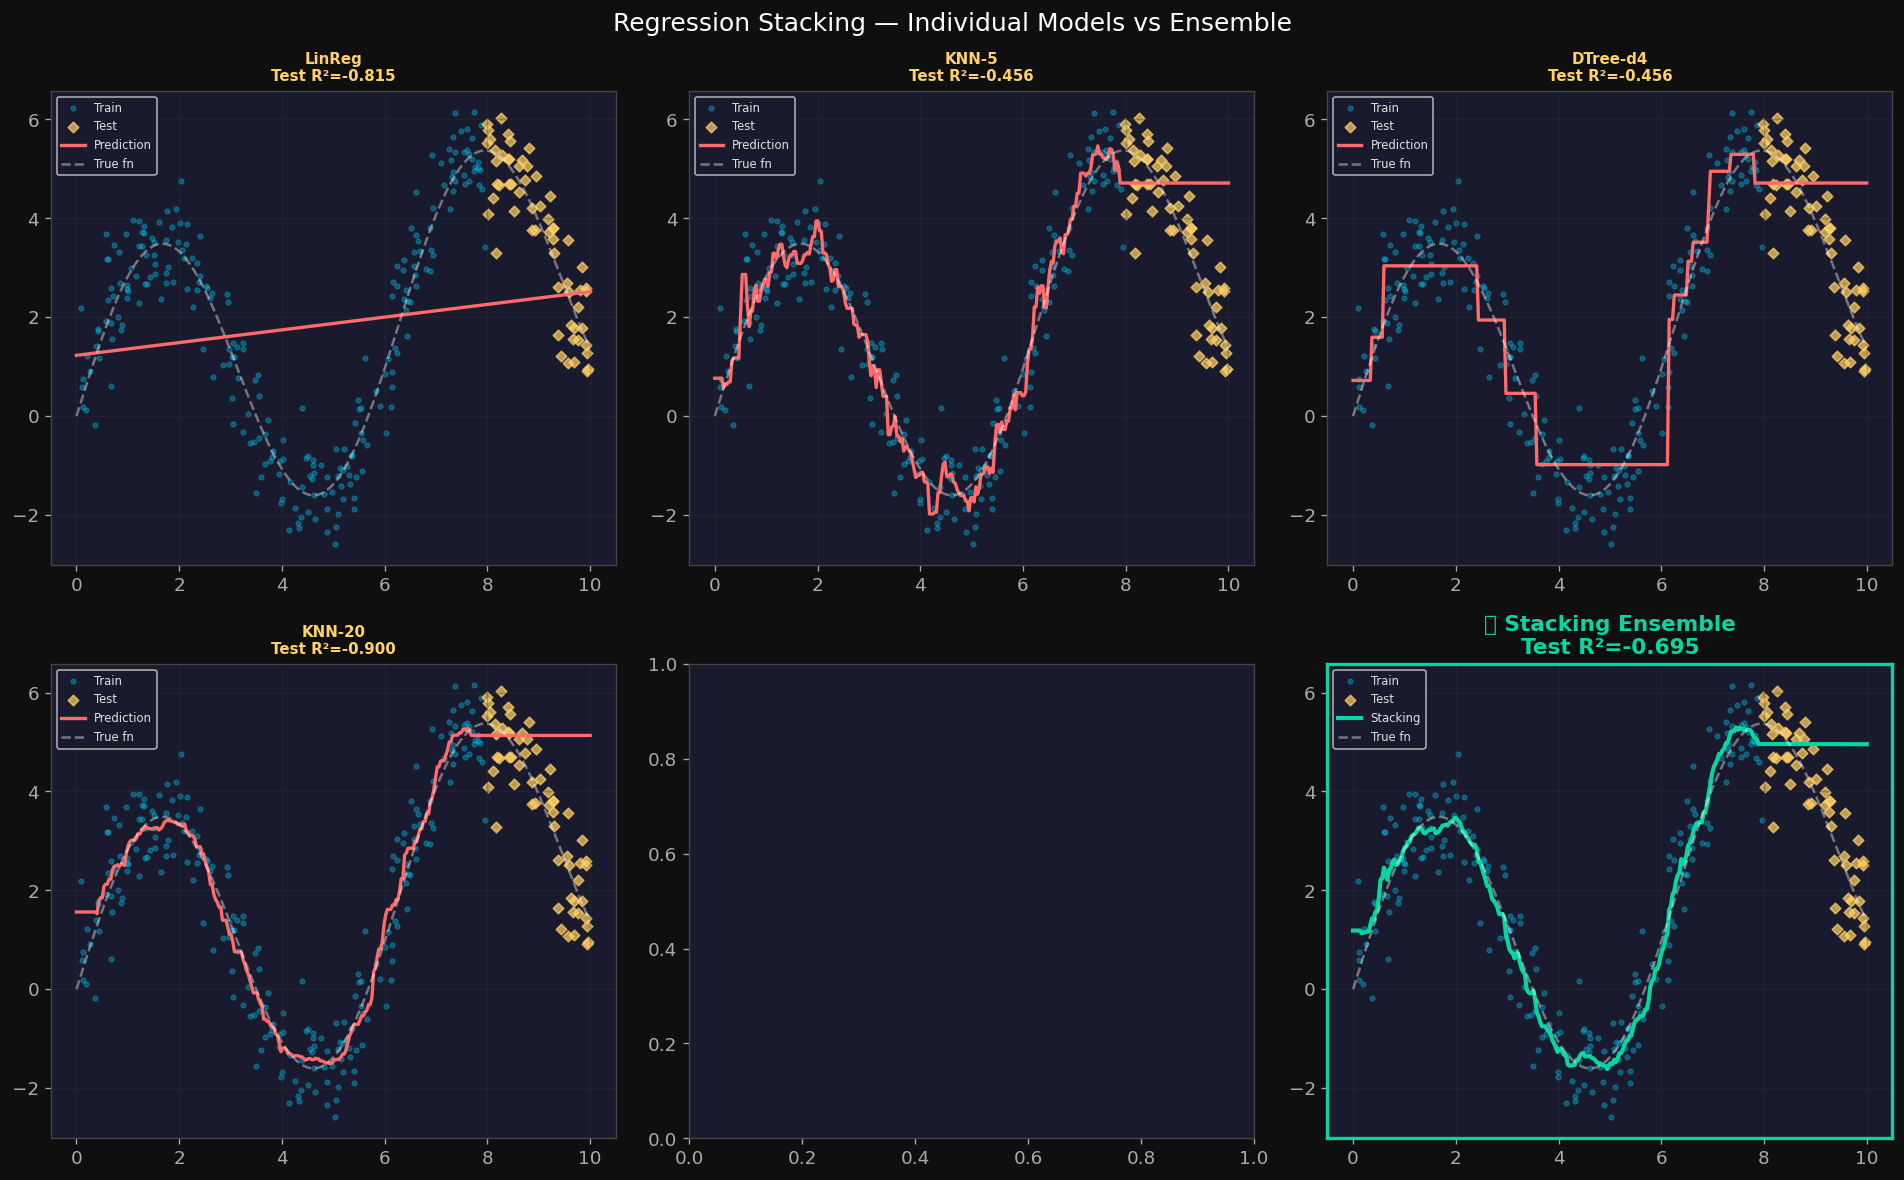

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  Visualize regression stacking on 1D slice
# ─────────────────────────────────────────────────────────────────────────────

# 1D version for clean visualization
X_1d = rng.uniform(0, 10, (300, 1))
y_1d = np.sin(X_1d.ravel()) * 3 + X_1d.ravel() * 0.3 + rng.randn(300) * 0.7
sort_idx = np.argsort(X_1d.ravel())
X_1d, y_1d = X_1d[sort_idx], y_1d[sort_idx]

n_tr1 = 240
X_1d_tr, X_1d_te = X_1d[:n_tr1], X_1d[n_tr1:]
y_1d_tr, y_1d_te = y_1d[:n_tr1], y_1d[n_tr1:]

base_1d = [
    ('LinReg',   LinearRegression(lr=0.05, n_iter=2000)),
    ('KNN-5',    KNNRegressor(k=5)),
    ('DTree-d4', DecisionTreeRegressor(max_depth=4)),
    ('KNN-20',   KNNRegressor(k=20)),
]
meta_1d = LinearRegression(lr=0.05, n_iter=2000)
stk_1d  = StackingRegressor(base_1d, meta_1d, k_folds=5, verbose=False)
stk_1d.fit(X_1d_tr, y_1d_tr)

X_plot = np.linspace(0, 10, 300).reshape(-1, 1)
y_true_plot = np.sin(X_plot.ravel()) * 3 + X_plot.ravel() * 0.3

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Regression Stacking — Individual Models vs Ensemble', fontsize=15, color='white')

for ax, (name, model) in zip(axes.ravel(), [(n,m) for n,m in base_1d]):
    m = copy.deepcopy(model); m.fit(X_1d_tr, y_1d_tr)
    r2 = m.score(X_1d_te, y_1d_te)
    ax.scatter(X_1d_tr, y_1d_tr, color=C[0], s=8, alpha=0.3, label='Train')
    ax.scatter(X_1d_te, y_1d_te, color=C[2], s=20, alpha=0.7, marker='D', label='Test')
    ax.plot(X_plot, m.predict(X_plot), color=C[1], lw=2, label='Prediction')
    ax.plot(X_plot, y_true_plot, color='white', lw=1.5, ls='--', alpha=0.4, label='True fn')
    ax.set_title(f'{name}\nTest R²={r2:.3f}', color=C[2], fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

# Stacking panel
ax_stk = axes[1, -1]
r2_stk = stk_1d.score(X_1d_te, y_1d_te)
ax_stk.scatter(X_1d_tr, y_1d_tr, color=C[0], s=8, alpha=0.3, label='Train')
ax_stk.scatter(X_1d_te, y_1d_te, color=C[2], s=20, alpha=0.7, marker='D', label='Test')
ax_stk.plot(X_plot, stk_1d.predict(X_plot), color=C[3], lw=2.5, label='Stacking')
ax_stk.plot(X_plot, y_true_plot, color='white', lw=1.5, ls='--', alpha=0.4, label='True fn')
ax_stk.set_title(f'🏆 Stacking Ensemble\nTest R²={r2_stk:.3f}', color=C[3])
ax_stk.legend(fontsize=7); ax_stk.grid(True, alpha=0.3)
for spine in ax_stk.spines.values():
    spine.set_edgecolor(C[3]); spine.set_linewidth(2)

plt.tight_layout()
plt.show()

---
## Part 10 — What Makes Good Base Models? Diversity Analysis

Comparing: Homogeneous vs Diverse base model sets



Homogeneous (4×LR)
  Test accuracy:     0.8571
  Mean OOF corr:     1.0000  (high — models agree)



Diverse (LR+KNN+DT+NB)
  Test accuracy:     0.9214
  Mean OOF corr:     0.8985  (high — models agree)



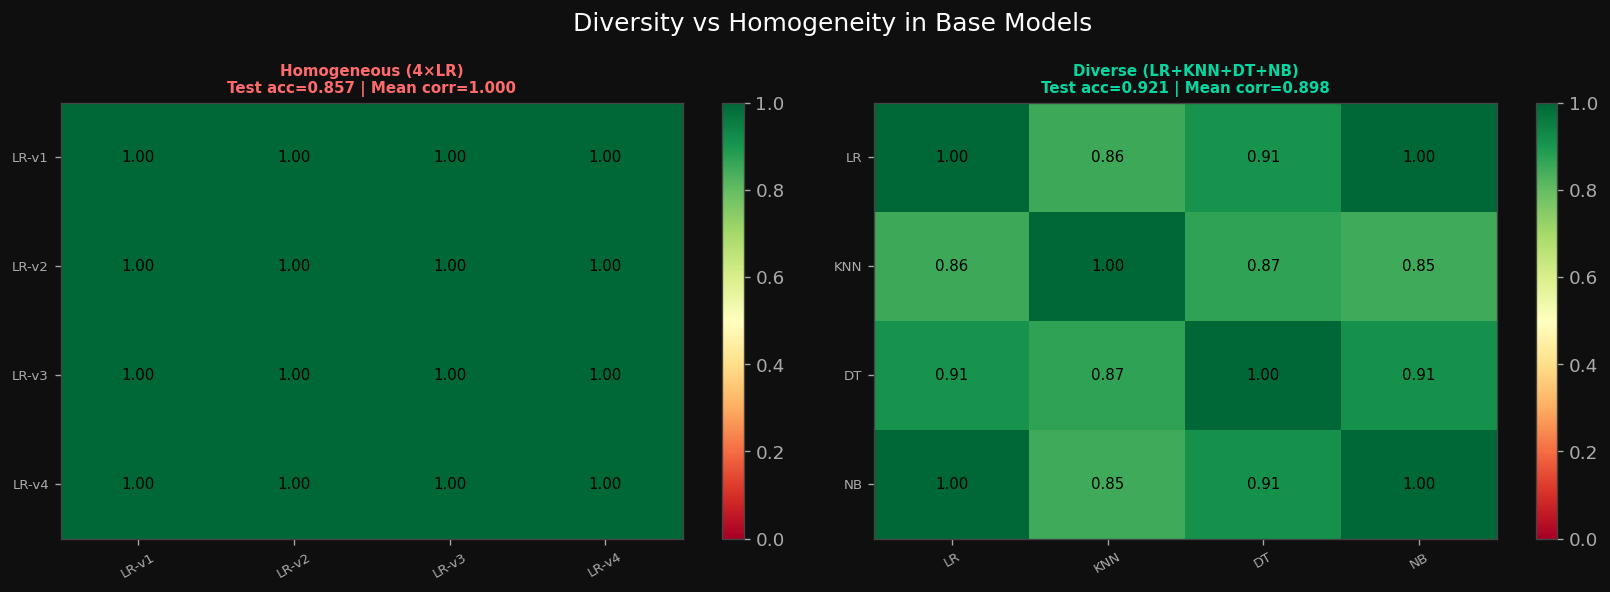

🔑 Low inter-model correlation = high diversity = better ensemble!
   Green = low correlation (good), Red = high correlation (bad for ensembling)


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  Show that diversity beats individual accuracy
# ─────────────────────────────────────────────────────────────────────────────

# Experiment: vary the diversity of base models
# Case A: 4 identical logistic regression models (same type, different seeds)
# Case B: 4 very different model families

print("Comparing: Homogeneous vs Diverse base model sets\n")

# Case A: All same type but different random inits
homogeneous = [
    ('LR-v1', LogisticRegression(lr=0.15, n_iter=500)),
    ('LR-v2', LogisticRegression(lr=0.20, n_iter=500)),
    ('LR-v3', LogisticRegression(lr=0.25, n_iter=500)),
    ('LR-v4', LogisticRegression(lr=0.18, n_iter=500)),
]

# Case B: Diverse model families
diverse = [
    ('LR',    LogisticRegression(lr=0.2, n_iter=600)),
    ('KNN',   KNNClassifier(k=7)),
    ('DT',    DecisionTreeClassifier(max_depth=4)),
    ('NB',    GaussianNaiveBayes()),
]

results_diversity = {}
for label, models in [('Homogeneous (4×LR)', homogeneous), ('Diverse (LR+KNN+DT+NB)', diverse)]:
    stk = StackingClassifier(
        base_models=models,
        meta_model=LogisticRegression(lr=0.3, n_iter=500),
        k_folds=5, verbose=False
    )
    stk.fit(X_stack_train, y_stack_train)
    te_acc = stk.score(X_te, y_te)
    oof_corr = np.corrcoef(stk.oof_predictions_.T)
    mean_corr = oof_corr[np.triu_indices(4, k=1)].mean()
    results_diversity[label] = {'acc': te_acc, 'corr': mean_corr, 'stk': stk}
    print(f"{label}")
    print(f"  Test accuracy:     {te_acc:.4f}")
    print(f"  Mean OOF corr:     {mean_corr:.4f}  ({'high — models agree' if mean_corr > 0.8 else 'low — models disagree = more diverse'})")
    print()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diversity vs Homogeneity in Base Models', fontsize=15, color='white')

for ax, (label, res) in zip(axes, results_diversity.items()):
    oof = res['stk'].oof_predictions_
    corr = np.corrcoef(oof.T)
    n = corr.shape[0]
    names = [n for n, _ in (homogeneous if 'Homo' in label else diverse)]

    im = ax.imshow(corr, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=30, fontsize=8)
    ax.set_yticklabels(names, fontsize=8)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                    fontsize=9, color='black' if corr[i,j] > 0.5 else 'white')
    plt.colorbar(im, ax=ax)
    acc = res['acc']; mc = res['corr']
    ax.set_title(f'{label}\nTest acc={acc:.3f} | Mean corr={mc:.3f}',
                 color=C[3] if 'Diverse' in label else C[1], fontsize=9)

plt.tight_layout()
plt.show()

print("🔑 Low inter-model correlation = high diversity = better ensemble!")
print("   Green = low correlation (good), Red = high correlation (bad for ensembling)")

---
## Part 11 — Passthrough Features & Feature Importance

Comparing: Stacking with and without passthrough features



No passthrough (meta sees only OOF preds)
  Meta-model input size: 4 features
  Test accuracy:         0.9500



Passthrough=True (meta sees OOF + original features)
  Meta-model input size: 6 features
  Test accuracy:         0.9500



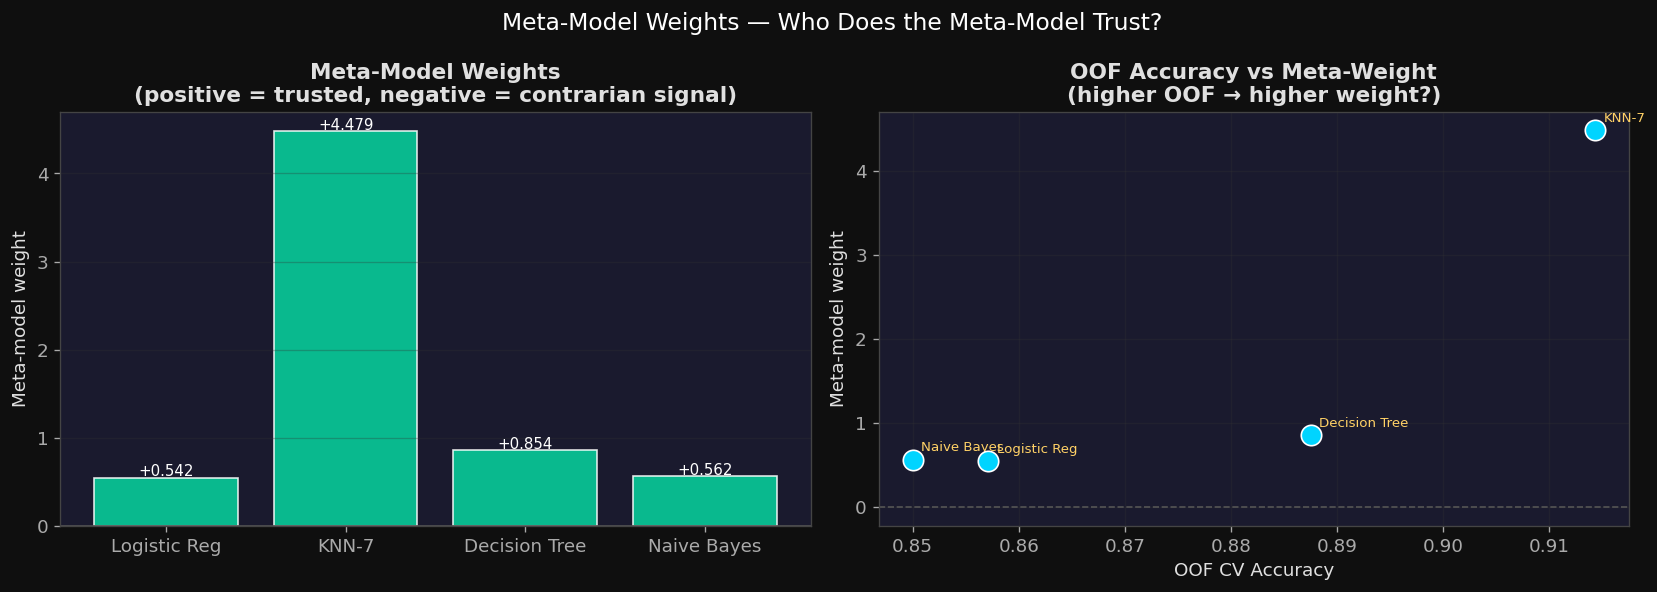


🔑 The meta-model doesn't always assign highest weight to the most accurate base model.
   It learns to exploit COMPLEMENTARY errors — sometimes a weaker model
   catches mistakes that the strong models miss.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  Passthrough features: should meta-model see original features too?
# ─────────────────────────────────────────────────────────────────────────────

print("Comparing: Stacking with and without passthrough features\n")

results_pt = {}
for passthrough, label in [(False, 'No passthrough\n(meta sees only OOF preds)'),
                            (True,  'Passthrough=True\n(meta sees OOF + original features)')]:
    stk = StackingClassifier(
        base_models=[('LR',LogisticRegression(lr=0.2,n_iter=600)),
                     ('KNN',KNNClassifier(k=7)),
                     ('DT',DecisionTreeClassifier(max_depth=4)),
                     ('NB',GaussianNaiveBayes())],
        meta_model=LogisticRegression(lr=0.3, n_iter=800),
        k_folds=5, passthrough=passthrough, verbose=False
    )
    stk.fit(X_stack_train, y_stack_train)
    te = stk.score(X_te, y_te)
    results_pt[label] = te
    meta_input_size = len(stk.meta_model.w)
    print(f"{label.replace(chr(10),' ')}")
    print(f"  Meta-model input size: {meta_input_size} features")
    print(f"  Test accuracy:         {te:.4f}\n")


# ─────────────────────────────────────────────────────────────────────────────
#  Feature importance from the meta-model weights
# ─────────────────────────────────────────────────────────────────────────────

# Train the stacker and inspect meta-model weights
final_stk = StackingClassifier(
    base_models=[('Logistic Reg', LogisticRegression(lr=0.2,n_iter=600)),
                 ('KNN-7',        KNNClassifier(k=7)),
                 ('Decision Tree',DecisionTreeClassifier(max_depth=4)),
                 ('Naive Bayes',  GaussianNaiveBayes())],
    meta_model=LogisticRegression(lr=0.3, n_iter=800),
    k_folds=5, verbose=False
)
final_stk.fit(X_stack_train, y_stack_train)

meta_weights = final_stk.meta_model.w
model_names_final = [n for n, _ in final_stk.base_models]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Meta-Model Weights — Who Does the Meta-Model Trust?', fontsize=14, color='white')

# Weight bar chart
ax = axes[0]
bar_colors = [C[3] if w > 0 else C[1] for w in meta_weights]
bars = ax.bar(model_names_final, meta_weights, color=bar_colors, alpha=0.85, edgecolor='white')
ax.axhline(0, color='#555', lw=1)
for bar, val in zip(bars, meta_weights):
    ax.text(bar.get_x()+bar.get_width()/2,
            val + (0.02 if val >= 0 else -0.04),
            f'{val:+.3f}', ha='center', fontsize=9, color='white')
ax.set_ylabel('Meta-model weight')
ax.set_title('Meta-Model Weights\n(positive = trusted, negative = contrarian signal)')
ax.grid(True, alpha=0.3, axis='y')

# OOF score vs meta-weight scatter
ax2 = axes[1]
oof_means = [np.mean(final_stk.oof_scores_[n]) for n in model_names_final]
ax2.scatter(oof_means, meta_weights, s=150, color=C[0], zorder=5, edgecolors='white')
for name, oof_sc, mw in zip(model_names_final, oof_means, meta_weights):
    ax2.annotate(name, (oof_sc, mw), xytext=(5, 5), textcoords='offset points',
                 fontsize=8, color=C[2])
ax2.axhline(0, color='#555', lw=1, ls='--')
ax2.set_xlabel('OOF CV Accuracy')
ax2.set_ylabel('Meta-model weight')
ax2.set_title('OOF Accuracy vs Meta-Weight\n(higher OOF → higher weight?)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🔑 The meta-model doesn't always assign highest weight to the most accurate base model.")
print("   It learns to exploit COMPLEMENTARY errors — sometimes a weaker model")
print("   catches mistakes that the strong models miss.")

---
## Part 12 — Full Competition-Style Pipeline

In ML competitions (Kaggle), stacking is the dominant winning strategy. Let's build a realistic pipeline.

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  Competition-style stacking pipeline on a richer dataset
# ─────────────────────────────────────────────────────────────────────────────

def make_competition_data(n=1000, seed=42):
    """Simulate a harder, realistic dataset with 6 features."""
    rng = np.random.RandomState(seed)
    n0, n1 = n*2//3, n//3

    X0 = rng.randn(n0, 6) * [1.5, 2.0, 1.2, 3.0, 1.0, 2.5] + [0, 1, -1, 2, 0, -2]
    X1 = rng.randn(n1, 6) * [2.0, 1.5, 2.0, 2.5, 1.5, 2.0] + [3, -1, 2, -1, 2, 1]
    X = np.vstack([X0, X1])
    y = np.hstack([np.zeros(n0), np.ones(n1)])
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

feat_names_comp = ['Age','Income','Score','Usage','Tenure','Activity']

X_comp, y_comp = make_competition_data(n=1200)

# Split: 70% train, 15% val, 15% test
rng2 = np.random.RandomState(99)
idx = rng2.permutation(len(y_comp))
n_tr_c = int(len(y_comp)*0.70)
n_val_c = int(len(y_comp)*0.15)
X_ctr  = X_comp[idx[:n_tr_c]];         y_ctr  = y_comp[idx[:n_tr_c]]
X_cval = X_comp[idx[n_tr_c:n_tr_c+n_val_c]]; y_cval = y_comp[idx[n_tr_c:n_tr_c+n_val_c]]
X_cte  = X_comp[idx[n_tr_c+n_val_c:]]; y_cte  = y_comp[idx[n_tr_c+n_val_c:]]
X_ctr, X_cval, X_cte = normalize(X_ctr, X_cval, X_cte)

X_comp_stack = np.vstack([X_ctr, X_cval])
y_comp_stack = np.hstack([y_ctr, y_cval])

print(f"Competition dataset: {len(X_comp)} samples, {X_comp.shape[1]} features")
print(f"Train: {len(X_ctr)} | Val: {len(X_cval)} | Test: {len(X_cte)}")
print(f"Class balance: {y_comp.mean():.1%}\n")

# Build a rich set of base models
comp_base = [
    ('LR-strong',  LogisticRegression(lr=0.2,  n_iter=1000, lam=0.001)),
    ('LR-reg',     LogisticRegression(lr=0.1,  n_iter=1000, lam=0.1)),
    ('KNN-3',      KNNClassifier(k=3)),
    ('KNN-11',     KNNClassifier(k=11)),
    ('DT-shallow', DecisionTreeClassifier(max_depth=3, min_samples_leaf=5)),
    ('DT-deep',    DecisionTreeClassifier(max_depth=6, min_samples_leaf=3)),
    ('NaiveBayes', GaussianNaiveBayes()),
]

print("Training competition stacking pipeline...")
comp_stacker = StackingClassifier(
    base_models=comp_base,
    meta_model=LogisticRegression(lr=0.3, n_iter=1000),
    k_folds=5, verbose=True
)
comp_stacker.fit(X_comp_stack, y_comp_stack)
print(f"\n🏆 Competition Stacker Test Accuracy: {comp_stacker.score(X_cte, y_cte):.4f}")

Competition dataset: 1200 samples, 6 features
Train: 840 | Val: 180 | Test: 180
Class balance: 33.3%

Training competition stacking pipeline...
  [1/7] Generating OOF for: LR-strong
  [2/7] Generating OOF for: LR-reg


  [3/7] Generating OOF for: KNN-3
  [4/7] Generating OOF for: KNN-11
  [5/7] Generating OOF for: DT-shallow


  [6/7] Generating OOF for: DT-deep


  [7/7] Generating OOF for: NaiveBayes
  Retraining base models on full training data...


  Training meta-model...
✅ Stacking training complete!

🏆 Competition Stacker Test Accuracy: 0.9778


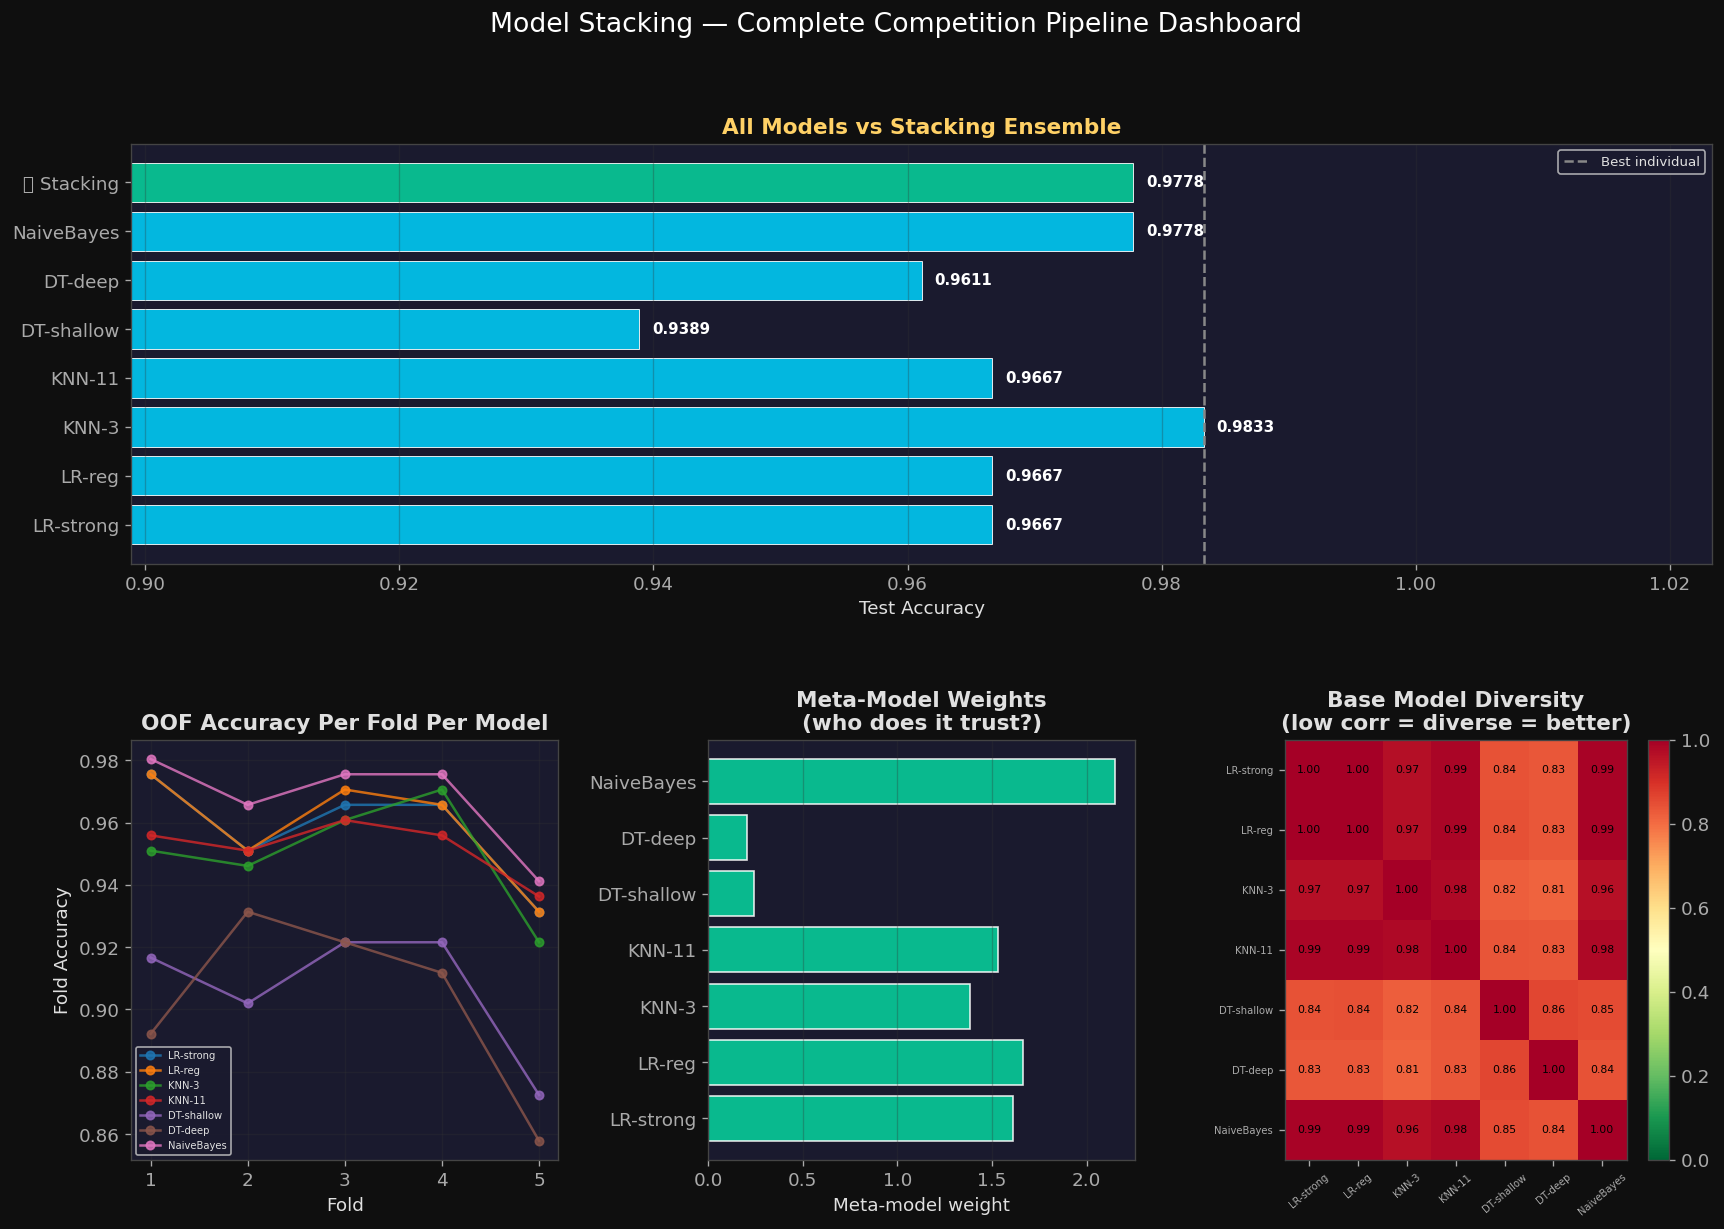

✅ Competition pipeline complete!


In [22]:
# ─────────────────────────────────────────────────────────────────────────────
#  Final comprehensive dashboard
# ─────────────────────────────────────────────────────────────────────────────

# Gather all individual model scores
indiv_scores = {}
for name, model in comp_base:
    m = copy.deepcopy(model)
    m.fit(X_comp_stack, y_comp_stack)
    indiv_scores[name] = m.score(X_cte, y_cte)
indiv_scores['🏆 Stacking'] = comp_stacker.score(X_cte, y_cte)

fig = plt.figure(figsize=(17, 11))
fig.suptitle('Model Stacking — Complete Competition Pipeline Dashboard', fontsize=16, color='white', y=0.98)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

# 1. Full accuracy comparison (wide)
names_all  = list(indiv_scores.keys())
scores_all = list(indiv_scores.values())
cols_all   = [C[0]]*len(comp_base) + [C[3]]
bars = ax1.barh(names_all, scores_all, color=cols_all, alpha=0.85, edgecolor='white', lw=0.6)
for bar, val in zip(bars, scores_all):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9, color='white', fontweight='bold')
ax1.axvline(max(scores_all[:-1]), color='#888', ls='--', lw=1.5, label='Best individual')
ax1.set_xlabel('Test Accuracy')
ax1.set_title('All Models vs Stacking Ensemble', color=C[2])
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='x')
ax1.set_xlim(min(scores_all)-0.04, max(scores_all)+0.04)

# 2. OOF convergence: how OOF accuracy stabilizes across folds
for bname, scores in comp_stacker.oof_scores_.items():
    ax2.plot(range(1, len(scores)+1), scores, 'o-', lw=1.5, ms=5, alpha=0.8, label=bname)
ax2.set_xlabel('Fold')
ax2.set_ylabel('Fold Accuracy')
ax2.set_title('OOF Accuracy Per Fold Per Model')
ax2.legend(fontsize=6)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 6))

# 3. Meta-model weights
mw = comp_stacker.meta_model.w
mn = [n for n, _ in comp_base]
bar_colors_mw = [C[3] if w > 0 else C[1] for w in mw]
ax3.barh(mn, mw, color=bar_colors_mw, alpha=0.85, edgecolor='white')
ax3.axvline(0, color='#555', lw=1)
ax3.set_xlabel('Meta-model weight')
ax3.set_title('Meta-Model Weights\n(who does it trust?)')
ax3.grid(True, alpha=0.3, axis='x')

# 4. OOF correlation heatmap
oof_c = comp_stacker.oof_predictions_
corr_c = np.corrcoef(oof_c.T)
n_c = corr_c.shape[0]
im = ax4.imshow(corr_c, cmap='RdYlGn_r', vmin=0, vmax=1, aspect='auto')
ax4.set_xticks(range(n_c)); ax4.set_yticks(range(n_c))
ax4.set_xticklabels([n for n, _ in comp_base], rotation=40, fontsize=6)
ax4.set_yticklabels([n for n, _ in comp_base], fontsize=6)
for i in range(n_c):
    for j in range(n_c):
        ax4.text(j, i, f'{corr_c[i,j]:.2f}', ha='center', va='center',
                 fontsize=6.5, color='white' if corr_c[i,j] < 0.6 else 'black')
plt.colorbar(im, ax=ax4)
ax4.set_title('Base Model Diversity\n(low corr = diverse = better)')

plt.savefig('stacking_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print("✅ Competition pipeline complete!")

---
## 📝 Summary — The Complete Stacking Cheatsheet

### Algorithm Recap

```
STACKING TRAINING:
  Input: (X_train, y_train), K folds, B base models, 1 meta-model

  1. For each base model b:
       For each fold k:
         Train model_b on all folds except k
         OOF_b[fold_k] = model_b.predict(X[fold_k])
       Retrain model_b on ALL X_train

  2. M_train = column_stack([OOF_1, OOF_2, ..., OOF_B])  shape: (m, B)

  3. meta_model.fit(M_train, y_train)

STACKING INFERENCE:
  M_test = column_stack([model_b.predict(X_test) for b in models])
  y_pred = meta_model.predict(M_test)
```

### When to Use Each Method

| Method | Use when | Avoid when |
|--------|----------|------------|
| **Hard Voting** | Models have similar performance | Probabilities matter |
| **Soft Voting** | Models output probabilities | Models are miscalibrated |
| **Blending** | Fast iteration, small teams | Data is scarce |
| **Stacking (2-level)** | Competition, production, max accuracy | Need fast training |
| **Stacking (3-level)** | Kaggle top-10, huge data | Risk of overfitting |

### Rules for Good Stacking

| Rule | Why |
|------|-----|
| **Always use OOF** | Prevents data leakage |
| **Diverse base models** | Low correlation = more improvement |
| **Simple meta-model** | Complex meta = overfitting to OOF |
| **More folds = better** | More OOF data = better meta-training |
| **Don't stack identical models** | No diversity = no gain |
| **Passthrough optional** | Helps when base models miss patterns |

---
> **Next Steps:** Stacking is the foundation of **AutoML** (automated model search + stacking), **Kaggle winning solutions** (often 3-4 level stacks), and is closely related to **boosting** (where each model corrects the previous one's errors in sequence rather than in parallel).